# 🐄 Livestock Auction Barn EDA
### Capstone Project — Emma's Merged Barns Data
---
**File:** `/content/drive/MyDrive/capstone/data/Emmas_merged_barns.xlsx`

| # | Section | Purpose |
|---|---------|---------|
| 1 | Setup & Mount Drive | Install deps, mount Google Drive |
| 2 | Load Data & Overview | Shape, dtypes, basic stats |
| 3 | Missing Value Heatmaps | Where are the gaps? |
| 4 | Head Count Analysis | Transaction volume proxy |
| 5 | Price Analysis | Mid-price trends by weight class |
| 6 | Price Comparison Across Barns | Cross-barn price level comparison |
| 7 | Sale Frequency & Calendar | Seasonality, day-of-week patterns |
| 8 | Six-Month Barn Extra Categories | Slaughter cows, cow-calf, bulls |
| 9 | Correlation Matrix | Cross-variable relationships |
| 10 | Steer vs Heifer Differential | Premium by weight class |
| 11 | B1 — Barn Completeness (SAM Gate) | Which barns qualify for model |
| 12 | B2 — Missing Data per Barn | Quality gate for imputation |
| 13 | B3 — Price Distributions | Benchmarks for unit economics |
| 14 | B4 — Seasonality Chart | Imputation validation |
| 15 | B5 — Barn-to-Barn Correlation | Key imputation defensibility test |
| 16 | B6 — Cow Volume Over Time | Transaction count estimate |
| 17 | Data Quality Summary | Model-ready output checklist |

## Section 1 — Setup & Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

FILE_PATH = '/content/drive/MyDrive/capstone/data/Emmas_merged_barns.xlsx'

# ── Global style defaults for readable charts ──
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# Colour palette — one distinct colour per barn (up to 20 SAM-eligible ones)
BARN_PALETTE = sns.color_palette('tab20', 20)

print("✅ Setup complete.")

Mounted at /content/drive
✅ Setup complete.


## Section 2 — Load Data & Basic Overview

In [2]:
all_df = pd.read_excel(FILE_PATH, sheet_name='all_merged',      parse_dates=['Date'])
six_df = pd.read_excel(FILE_PATH, sheet_name='six_month_barns', parse_dates=['Date'])

# ── Clean Barn column ──────────────────────────────────────
for df in [all_df, six_df]:
    df['Barn'] = df['Barn'].astype(str).str.strip()
    df['Barn'] = df['Barn'].replace({'nan': pd.NA, 'NaT': pd.NA, '': pd.NA})
    # Drop rows whose Barn value is clearly a stray datetime string
    mask_bad = df['Barn'].str.match(r'^\d{4}-\d{2}-\d{2}', na=False)
    if mask_bad.any():
        print(f"⚠  Dropping {mask_bad.sum()} rows with datetime-valued Barn:")
        display(df.loc[mask_bad, ['Date','Barn']])
        df.drop(df[mask_bad].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"all_merged  : {all_df.shape[0]:,} rows × {all_df.shape[1]} cols")
print(f"six_month   : {six_df.shape[0]:,} rows × {six_df.shape[1]} cols")

for name, df in [("all_merged", all_df), ("six_month_barns", six_df)]:
    print(f"\n{'='*55}\nSHEET: {name}\n{'='*55}")
    print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
    barn_list = sorted(df['Barn'].dropna().unique().tolist())
    print(f"Barns ({len(barn_list)}): {barn_list}")
    info = pd.DataFrame({'dtype': df.dtypes,
                         'non_null': df.notna().sum(),
                         'null_pct': (df.isna().mean()*100).round(1)})
    display(info)
    display(df.describe())

⚠  Dropping 2 rows with datetime-valued Barn:


,Date,Barn
373,2026-02-28,2026-02-28 00:00:00
375,2026-02-28,2026-02-28 00:00:00


all_merged  : 913 rows × 50 cols
six_month   : 341 rows × 38 cols

SHEET: all_merged
Date range : 2024-01-16 → 2026-03-05
Barns (45): ['Beeville Livestock Commission', 'Brazos Valley', 'Brenham', 'Cattlemans Brenham', 'Columbus', 'Comanche', 'Comanche Livestock Exchange', 'Coryell', 'Cuero', 'Decatur', 'East Texas', 'Eden livestock', 'Edinburg', 'El Campo', 'Emory Livestock Auction', 'Flatonia Livestock Auction', 'Floydada Livestock Sales Co', 'Four County', 'Giddings Livestock Commission', 'Gillespie Livestock Co Inc', 'Gonzales', 'Gonzales Livestock', 'Gulf Coast Livestock Market LLC', 'Haletsville Livestock', 'Hondo Livestock Auction', 'Hunt Livestock Exchange, LLC', 'Jordan Cattle', 'Karnes', 'La grange(Flatonia)', 'Live Oak', 'Livingston', 'Lonestar Stockyards', 'Lonestar Stockyards (Video/Internet Auction)', 'Milam County Livestock Auction', 'Nacogdoches Livestock', 'Navasota', 'Pearsall', 'Producers Livestock Auction Co.', 'Raywood', 'Southwest Livestock Exchange', 'Sulphur Spri

,dtype,non_null,null_pct
Date,datetime64[ns],913,0.00
Barn,object,913,0.00
Head_Count,float64,840,8.00
Steer_200-300_Low,float64,889,2.60
Steer_200-300_High,float64,896,1.90
Steer_300-400_Low,float64,901,1.30
Steer_300-400_High,float64,908,0.50
Steer_400-500_Low,float64,904,1.00
Steer_400-500_High,float64,903,1.10
Steer_500-600_Low,float64,908,0.50


,Date,Head_Count,Steer_200-300_Low,Steer_200-300_High,Steer_300-400_Low,Steer_300-400_High,Steer_400-500_Low,Steer_400-500_High,Steer_500-600_Low,Steer_500-600_High,Steer_600-700_Low,Steer_600-700_High,Steer_700-800_Low,Steer_700-800_High,Steer_800-900_Low,Steer_800-900_High,Steer_900-1000_Low,Steer_900-1000_High,Steer_1000+_Low,Steer_1000+_High,Heifer_200-300_Low,Heifer_200-300_High,Heifer_300-400_Low,Heifer_300-400_High,Heifer_400-500_Low,Heifer_400-500_High,Heifer_500-600_Low,Heifer_500-600_High,Heifer_600-700_Low,Heifer_600-700_High,Heifer_700-800_Low,Heifer_700-800_High,Heifer_800-900_Low,Heifer_800-900_High,Heifer_900-1000_Low,Heifer_900-1000_High,Heifer_1000+_Low,Heifer_1000+_High,SlaughterCow_High_Low,SlaughterCow_High_High,SlaughterCow_Low_Low,SlaughterCow_Low_High,PackerBulls_Low,PackerBulls_High,CowCalf_Pairs_Low,CowCalf_Pairs_High,Replacement_Cows_Low,Replacement_Cows_High
count,913,840.00,889.00,896.00,901.00,908.00,904.00,903.00,908.00,908.00,900.00,899.00,782.00,782.00,125.00,118.00,3.00,3.00,1.00,1.00,852.00,894.00,866.00,892.00,904.00,903.00,908.00,908.00,899.00,898.00,663.00,663.00,104.00,96.00,2.00,2.00,1.00,1.00,452.00,409.00,407.00,403.00,412.00,400.00,196.00,210.00,211.00,211.00
mean,2025-09-08 06:31:09.003286016,1042.12,222.19,308.57,206.58,275.65,181.52,243.61,167.24,213.35,154.57,187.43,164.51,191.13,117.38,138.25,294.33,301.00,307.00,307.00,210.85,271.08,198.19,241.43,169.80,219.81,155.27,193.70,146.89,173.96,134.73,158.28,86.79,106.54,285.00,285.00,260.00,260.00,363.49,485.13,316.58,416.70,108.69,127.15,2042.46,2808.69,1151.19,2316.04
min,2024-01-16 00:00:00,79.00,1.00,3.50,1.00,2.88,1.00,1.00,1.00,1.00,1.00,1.00,1.00,2.13,1.75,2.30,233.00,233.00,307.00,307.00,2.00,1.00,1.35,1.00,1.00,2.97,1.00,1.35,1.00,1.00,1.25,1.35,1.65,2.02,275.00,275.00,260.00,260.00,0.90,1.23,0.45,1.02,0.81,1.55,20.00,40.00,122.22,220.00
25%,2025-06-11 00:00:00,595.00,4.20,5.95,4.00,5.40,3.65,4.75,3.31,4.20,3.02,3.75,2.80,3.55,2.15,3.17,274.00,282.25,307.00,307.00,3.92,5.40,3.70,4.90,3.40,4.50,3.12,4.10,2.80,3.67,2.52,3.30,2.00,2.84,280.00,280.00,260.00,260.00,107.88,141.00,116.00,135.00,1.50,1.97,1700.00,800.00,277.78,527.80
50%,2025-09-26 00:00:00,891.00,200.00,411.00,280.00,420.00,240.00,345.00,220.00,319.00,210.00,280.00,235.00,284.50,3.40,3.67,315.00,331.50,307.00,307.00,300.00,330.00,285.00,355.00,237.50,315.00,217.50,295.00,200.00,251.00,180.00,235.00,3.11,3.48,285.00,285.00,260.00,260.00,140.00,157.00,135.00,146.00,146.25,174.50,1800.00,3300.00,1100.00,2800.00
75%,2025-12-13 00:00:00,1243.75,417.00,575.00,385.00,521.25,350.00,460.00,320.00,404.00,290.00,362.25,295.00,335.00,280.00,303.75,325.00,335.00,307.00,307.00,379.00,510.00,350.00,450.00,316.25,420.00,290.00,365.00,290.00,332.88,270.00,310.00,221.25,257.50,290.00,290.00,260.00,260.00,155.00,174.00,152.00,162.00,165.00,190.00,3000.00,4000.00,1800.00,3237.50
max,2026-03-05 00:00:00,6931.00,684.75,975.00,667.50,1450.00,570.00,1800.00,513.50,1650.00,540.00,490.00,404.00,540.00,345.00,364.00,335.00,338.50,307.00,307.00,800.00,1400.00,1700.00,1450.00,519.37,1900.00,460.00,570.00,409.50,580.00,460.00,427.50,310.00,332.00,295.00,295.00,260.00,260.00,3425.00,4400.00,2850.00,3425.00,200.00,625.00,4050.00,5150.00,3400.00,4500.00
std,NaN,755.31,223.31,310.13,204.12,269.75,181.53,241.50,165.31,211.12,152.55,182.29,142.26,162.25,140.49,154.50,54.05,58.99,NaN,NaN,202.15,273.67,198.67,237.47,168.44,220.27,152.78,189.06,144.76,169.97,132.74,153.76,118.93,135.75,14.14,14.14,NaN,NaN,652.70,866.36,500.40,674.10,72.84,91.13,1195.54,1614.95,728.93,1276.41



SHEET: six_month_barns
Date range : 2025-01-04 → 2026-02-28
Barns (7): ['Brenham', 'Columbus', 'Coryell', 'Cuero', 'Four County', 'Gonzales', 'Livingston']


,dtype,non_null,null_pct
Date,datetime64[ns],341,0.00
Barn,object,341,0.00
Head_Count,float64,286,16.10
Steer_200-300_Low,float64,340,0.30
Steer_200-300_High,float64,340,0.30
Steer_300-400_Low,float64,341,0.00
Steer_300-400_High,float64,341,0.00
Steer_400-500_Low,float64,341,0.00
Steer_400-500_High,float64,340,0.30
Steer_500-600_Low,float64,341,0.00


,Date,Head_Count,Steer_200-300_Low,Steer_200-300_High,Steer_300-400_Low,Steer_300-400_High,Steer_400-500_Low,Steer_400-500_High,Steer_500-600_Low,Steer_500-600_High,Steer_600-700_Low,Steer_600-700_High,Steer_700-800_Low,Steer_700-800_High,Heifer_200-300_Low,Heifer_200-300_High,Heifer_300-400_Low,Heifer_300-400_High,Heifer_400-500_Low,Heifer_400-500_High,Heifer_500-600_Low,Heifer_500-600_High,Heifer_600-700_Low,Heifer_600-700_High,Heifer_700-800_Low,Heifer_700-800_High,SlaughterCow_High_Low,SlaughterCow_High_High,SlaughterCow_Low_Low,SlaughterCow_Low_High,PackerBulls_Low,PackerBulls_High,CowCalf_Pairs_Low,CowCalf_Pairs_High,Replacement_Cows_Low,Replacement_Cows_High
count,341,286.00,340.00,340.00,341.00,341.00,341.00,340.00,341.00,341.00,340.00,340.00,233.00,233.00,340.00,340.00,341.00,341.00,341.00,341.00,341.00,341.00,340.00,340.00,177.00,177.00,156.00,156.00,102.00,102.00,155.00,155.00,133.00,133.00,143.00,143.00
mean,2025-07-30 15:24:48.563049728,970.63,263.12,366.71,232.68,318.38,208.81,283.72,192.96,246.47,180.04,219.35,245.77,284.24,239.38,327.50,212.01,280.00,196.34,258.60,179.82,230.39,172.03,207.18,215.50,255.64,91.10,100.77,133.10,146.25,107.27,123.17,2491.54,3741.73,1380.42,2976.57
min,2025-01-04 00:00:00,114.00,2.15,4.00,2.15,4.00,2.00,3.40,1.95,2.85,1.95,2.65,2.47,3.05,2.10,3.60,2.05,3.40,2.00,3.10,1.90,2.25,1.90,2.30,2.23,2.67,0.90,1.23,100.00,119.00,1.02,1.55,1475.00,2150.00,900.00,1700.00
25%,2025-04-26 00:00:00,703.75,4.88,6.00,4.45,5.30,3.90,4.65,3.55,4.10,3.17,3.65,235.00,290.00,4.51,5.55,3.95,4.80,3.67,4.35,3.40,4.00,2.94,3.47,210.00,253.00,1.20,1.64,125.00,140.00,1.55,1.94,1800.00,3200.00,900.00,2650.00
50%,2025-08-02 00:00:00,913.00,400.00,517.50,330.00,475.00,290.00,426.00,275.00,370.00,270.00,326.00,280.00,320.00,340.00,435.00,300.00,410.00,280.00,380.00,265.00,325.00,235.00,295.00,260.00,301.00,130.00,141.00,131.00,145.00,150.00,181.00,2000.00,3700.00,1400.00,3000.00
75%,2025-10-29 00:00:00,1201.25,425.00,600.00,390.00,530.00,359.00,475.00,321.00,416.00,310.00,370.00,302.00,345.00,400.00,550.00,350.00,475.00,325.00,440.00,300.00,395.00,295.00,350.00,282.00,330.00,141.00,158.25,145.00,155.00,169.00,192.50,3250.00,4250.00,1800.00,3300.00
max,2026-02-28 00:00:00,2101.00,684.75,950.00,627.75,690.00,554.00,630.00,513.50,570.00,451.00,490.00,404.00,435.00,670.00,815.00,568.25,650.00,497.25,570.00,460.00,570.00,409.50,475.00,335.00,380.00,165.00,199.00,159.00,181.00,191.00,208.00,4000.00,5000.00,2000.00,4500.00
std,NaN,368.08,218.68,308.22,195.02,262.27,174.72,232.64,160.43,203.27,148.50,180.17,99.44,112.95,199.97,275.10,177.30,231.58,163.28,213.38,149.30,191.42,142.57,171.04,101.81,118.95,66.46,73.78,13.59,13.52,77.42,88.43,878.46,676.92,425.62,606.86


## Section 3 — Missing Value Heatmaps

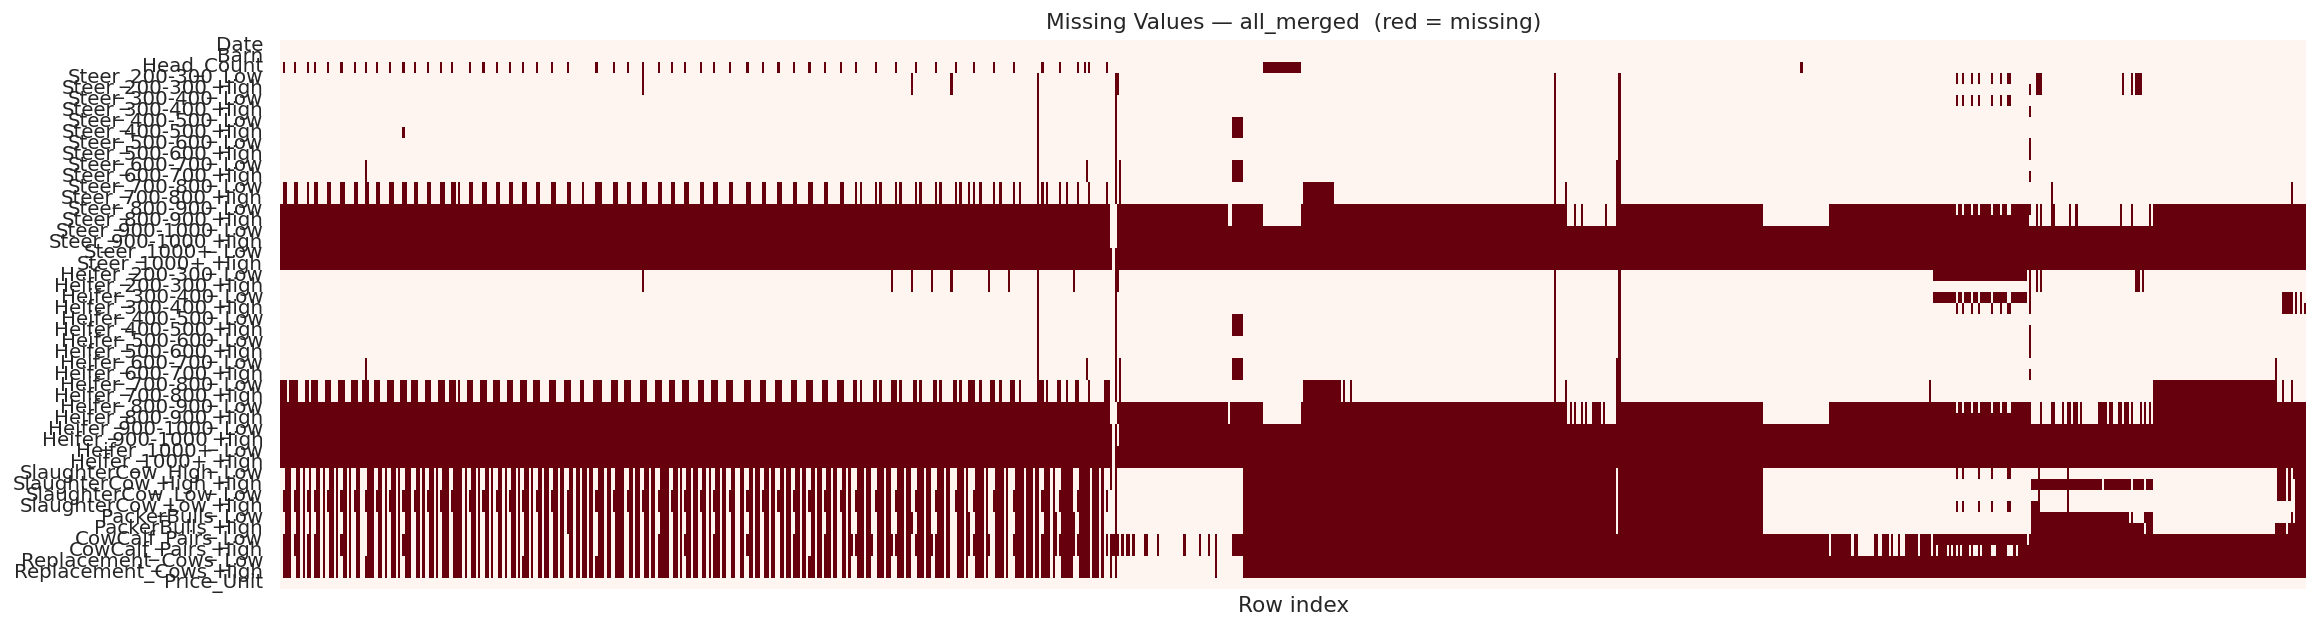

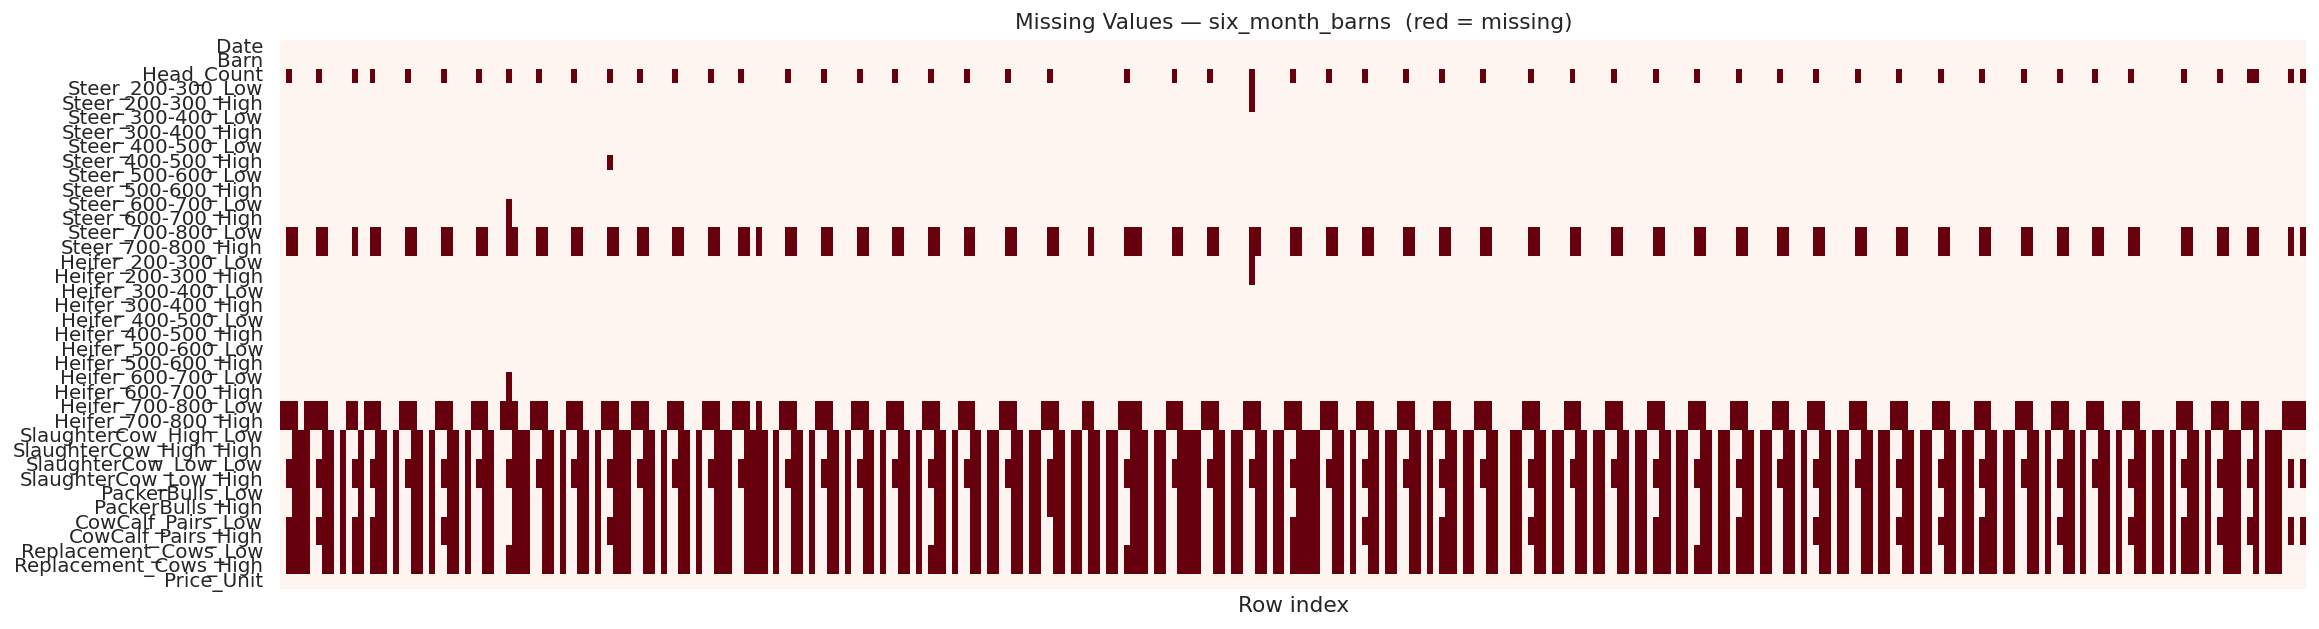

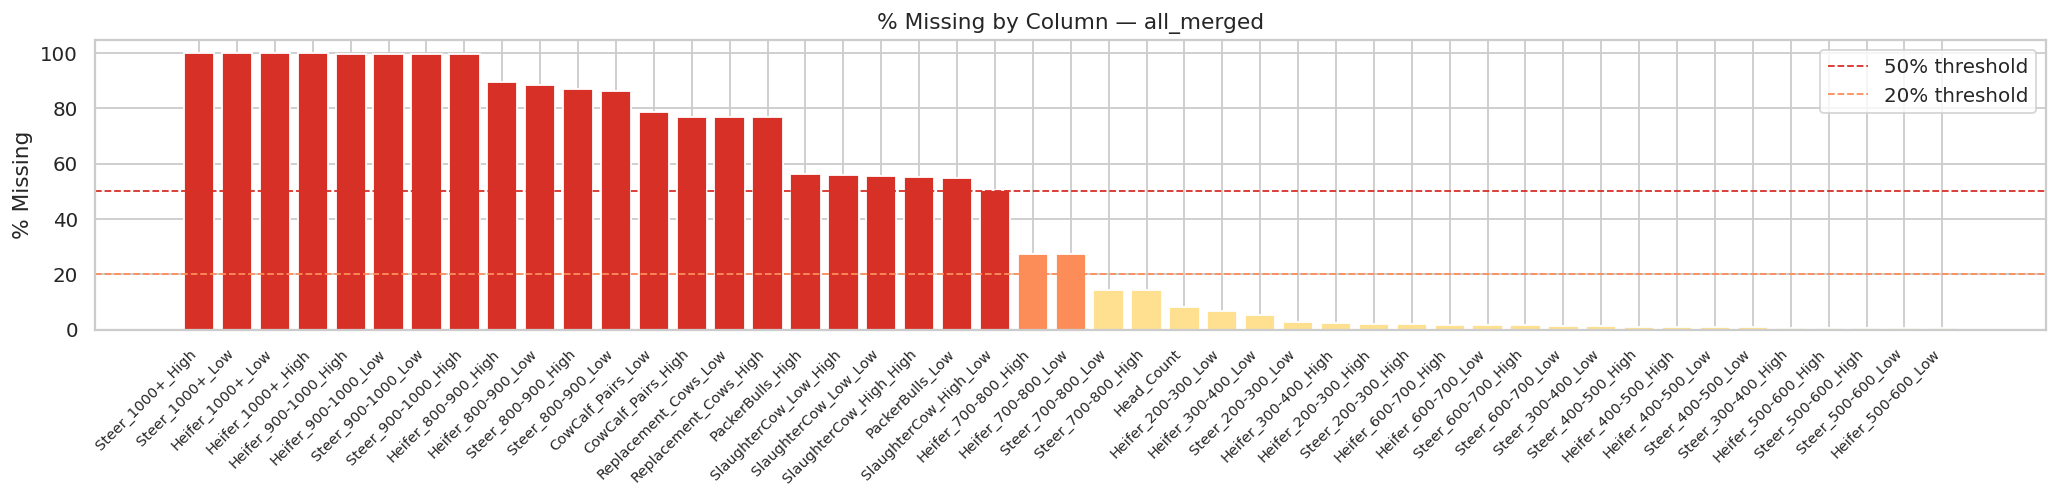

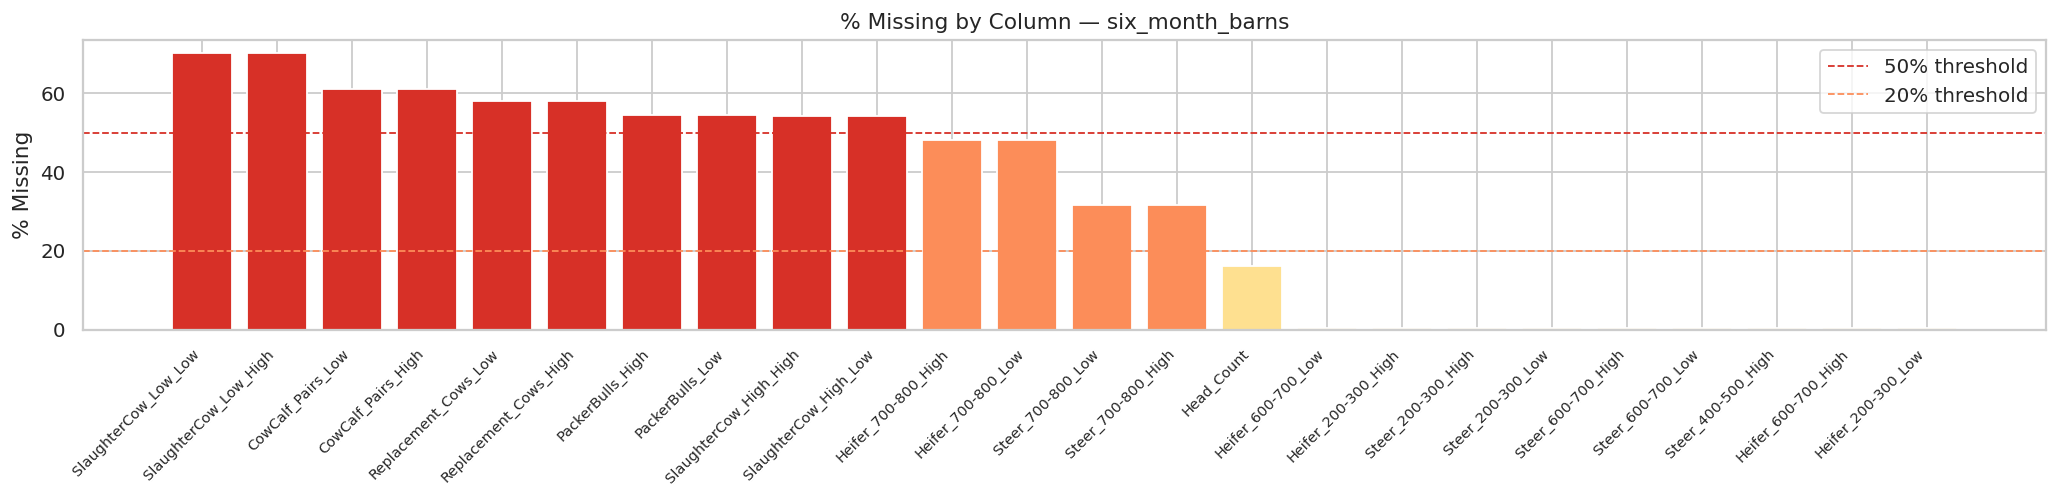

In [3]:
# ── 3a. Row-level heatmap ─────────────────────────────────
for name, df in [("all_merged", all_df), ("six_month_barns", six_df)]:
    fig, ax = plt.subplots(figsize=(18, 5))
    sns.heatmap(df.isnull().astype(int).T, ax=ax, cbar=False, cmap='Reds',
                yticklabels=True, xticklabels=False)
    ax.set_title(f'Missing Values — {name}  (red = missing)')
    ax.set_xlabel('Row index')
    plt.tight_layout()
    plt.show()

# ── 3b. % missing per column, sorted, colour-coded by severity ───
for name, df in [("all_merged", all_df), ("six_month_barns", six_df)]:
    null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    if null_pct.empty:
        continue
    colors = ['#d73027' if v >= 50 else '#fc8d59' if v >= 20 else '#fee090'
              for v in null_pct.values]
    fig, ax = plt.subplots(figsize=(16, 4))
    bars = ax.bar(range(len(null_pct)), null_pct.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(null_pct)))
    ax.set_xticklabels(null_pct.index, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('% Missing')
    ax.set_title(f'% Missing by Column — {name}')
    ax.axhline(50, color='#d73027', linestyle='--', linewidth=1, label='50% threshold')
    ax.axhline(20, color='#fc8d59', linestyle='--', linewidth=1, label='20% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Section 4 — Head Count Analysis

Head Count Summary by Barn


,sale_days,avg_head,median_head,total_head,min_head,max_head
Barn,,,,,,
Jordan Cattle,55,2912.00,2504.00,160182.00,502.00,6931.00
Cuero,47,1360.00,1386.00,63913.00,418.00,2101.00
Nacogdoches Livestock,44,1297.00,1298.00,57058.00,475.00,2104.00
Gonzales,55,988.00,959.00,54313.00,300.00,1640.00
Gonzales Livestock,55,988.00,959.00,54313.00,300.00,1640.00
Emory Livestock Auction,55,937.00,765.00,51537.00,273.00,1768.00
Columbus,54,924.00,898.00,49882.00,330.00,1389.00
Coryell,47,1014.00,1025.00,47653.00,114.00,2039.00
"Tri-County Livestock Market, Inc.",48,892.00,904.00,42818.00,171.00,1362.00


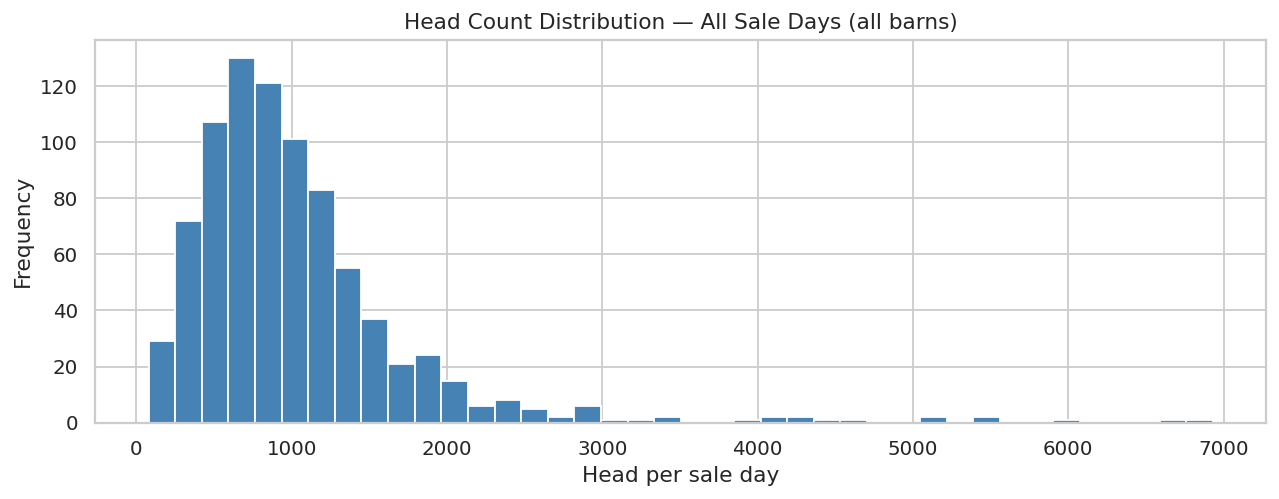

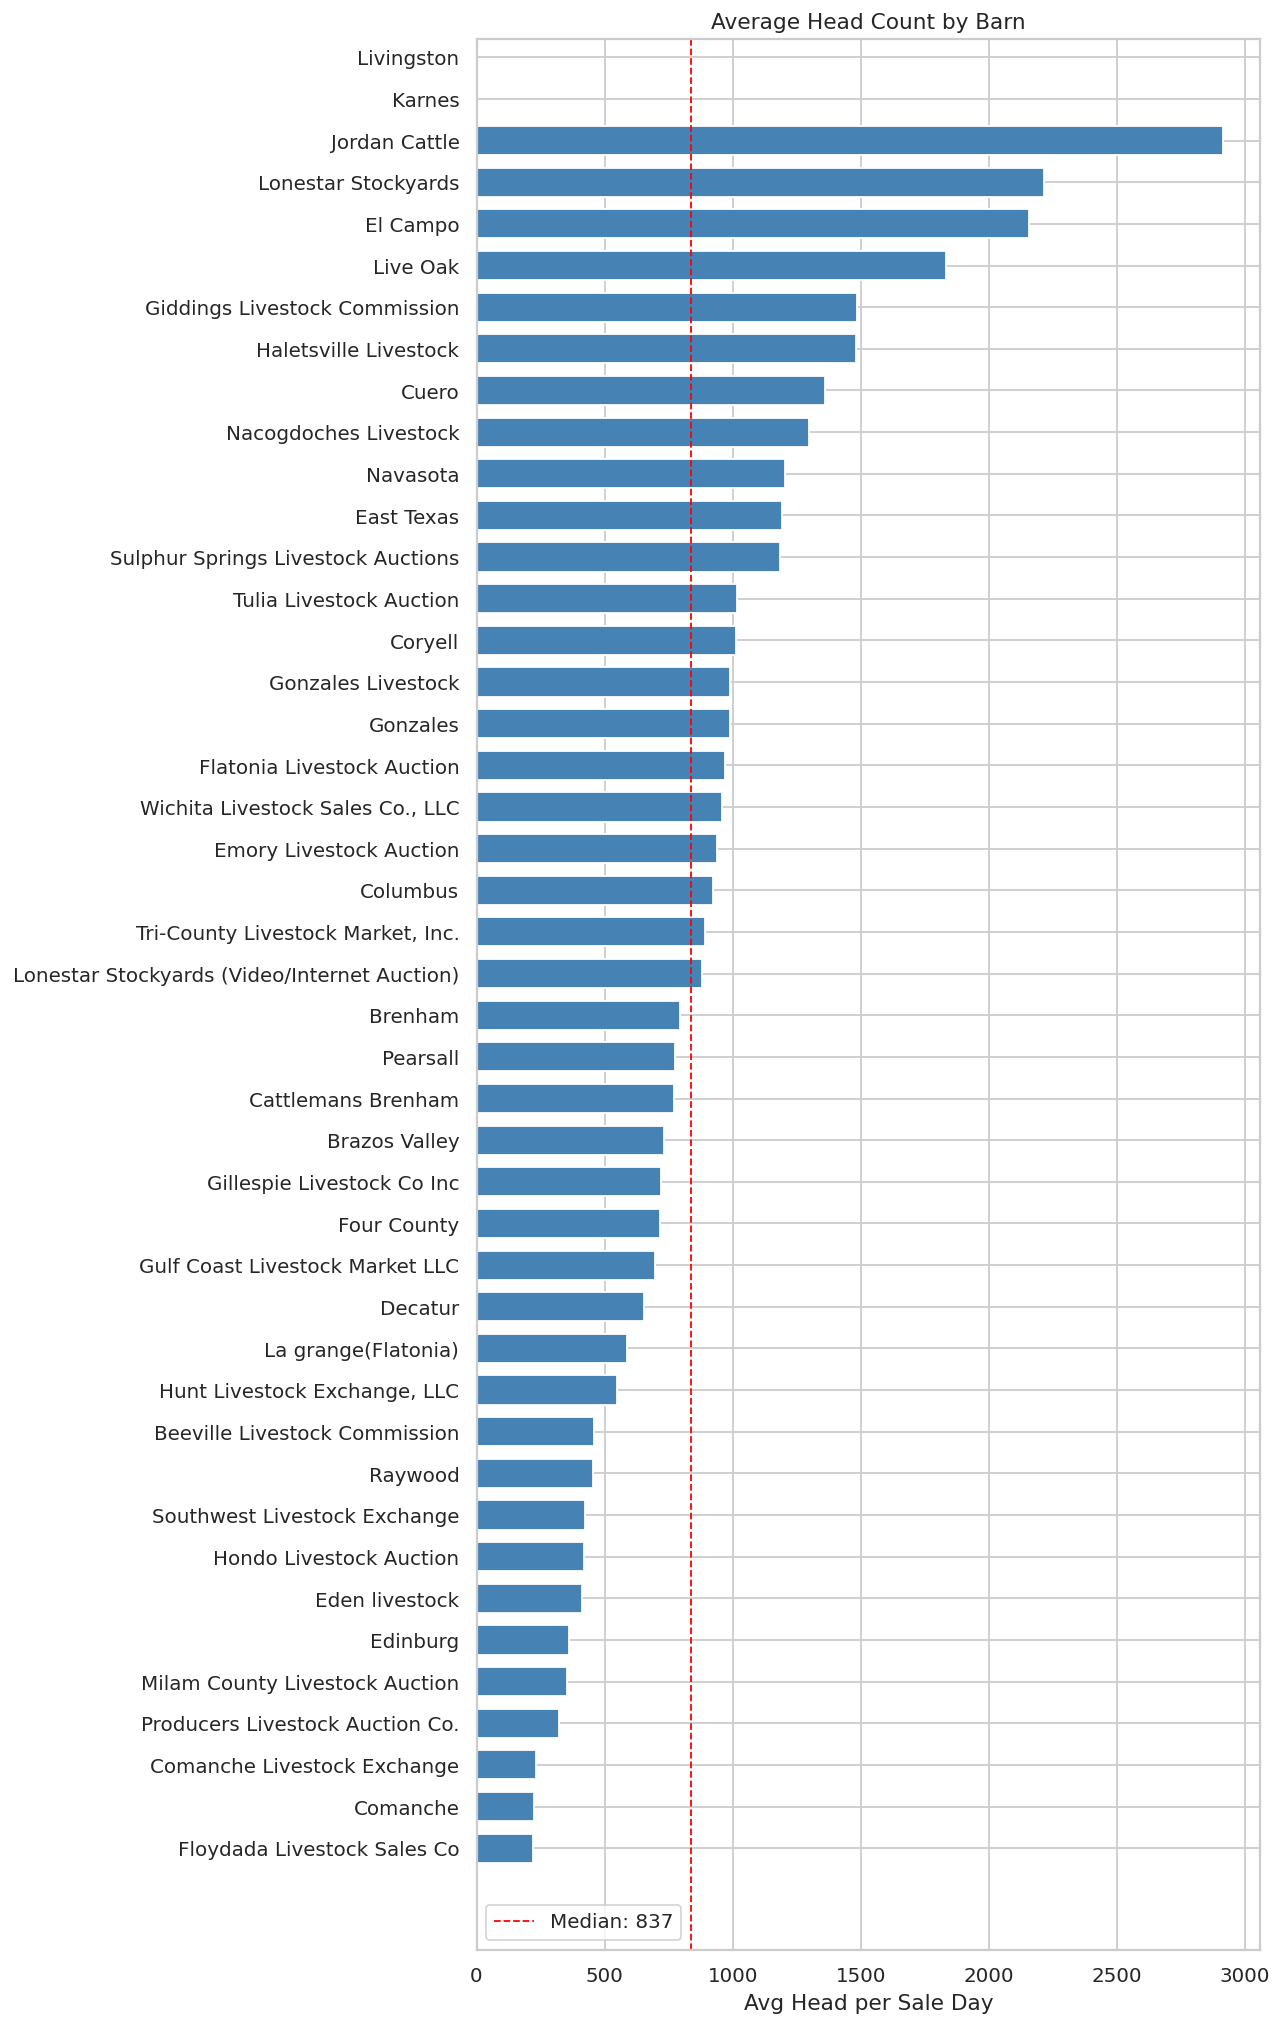

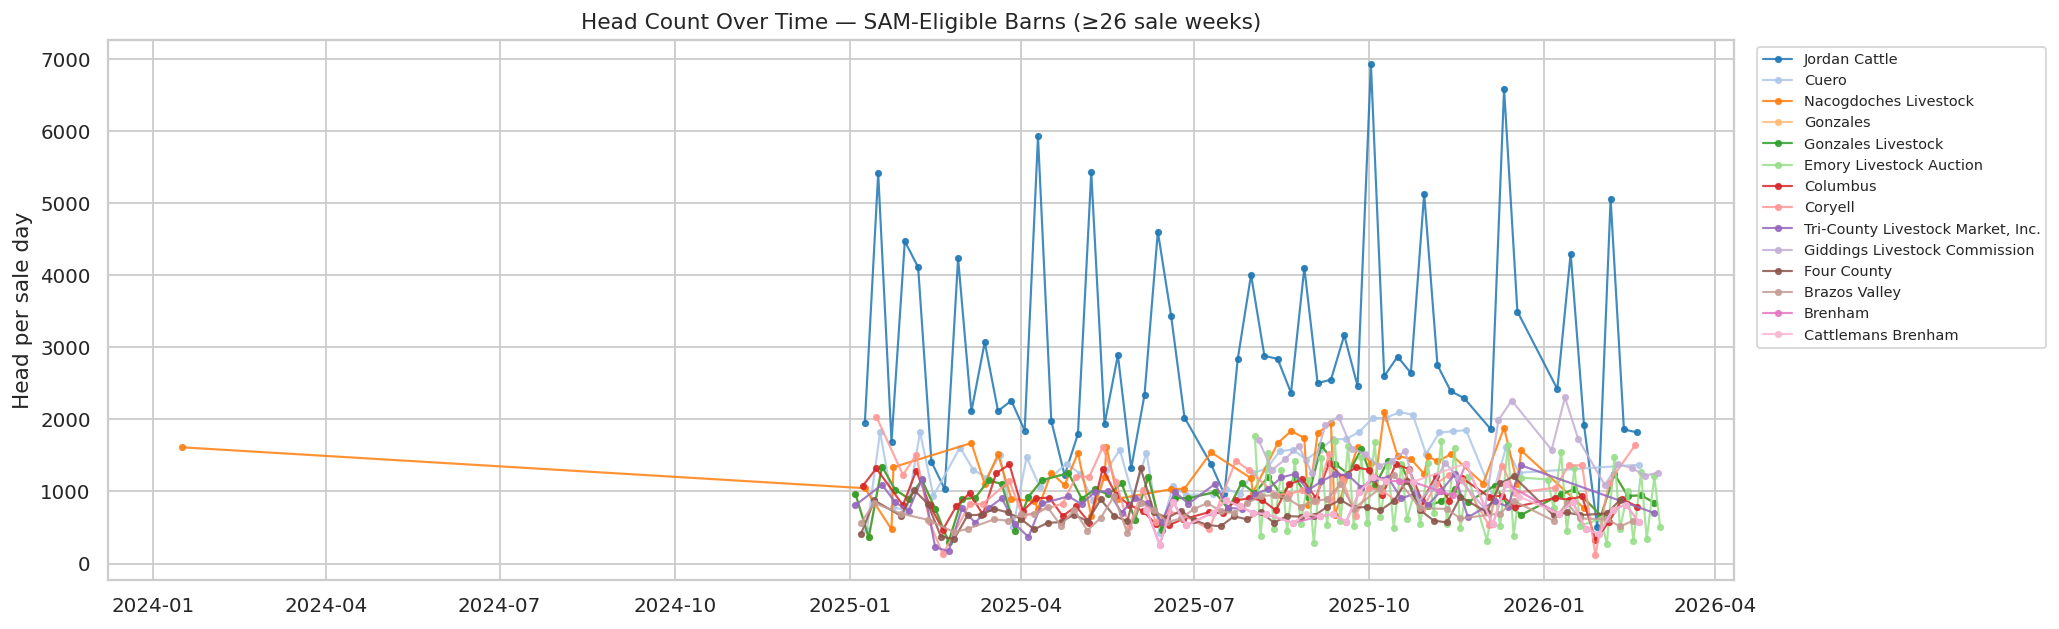

Note: 31 barns with <26 obs omitted for clarity.


In [4]:
# ── 4a. Summary table ─────────────────────────────────────
hc = (all_df.groupby('Barn')['Head_Count']
      .agg(['count','mean','median','sum','min','max'])
      .rename(columns={'count':'sale_days','mean':'avg_head',
                       'median':'median_head','sum':'total_head',
                       'min':'min_head','max':'max_head'})
      .sort_values('total_head', ascending=False))
print("Head Count Summary by Barn")
display(hc.round(0))

# ── 4b. Distribution histogram ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
all_df['Head_Count'].dropna().hist(bins=40, ax=ax,
    color='steelblue', edgecolor='white')
ax.set_title('Head Count Distribution — All Sale Days (all barns)')
ax.set_xlabel('Head per sale day')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# ── 4c. Horizontal bar chart: avg head per barn ───────────
hc_sorted = hc.sort_values('avg_head')
fig, ax = plt.subplots(figsize=(10, max(5, len(hc_sorted)*0.35)))
colors = ['#4e79a7' if v else '#bab0ac'
          for v in hc_sorted['avg_head'] > hc_sorted['avg_head'].median()]
ax.barh(hc_sorted.index, hc_sorted['avg_head'], color='steelblue',
        edgecolor='white', height=0.7)
ax.set_xlabel('Avg Head per Sale Day')
ax.set_title('Average Head Count by Barn')
ax.axvline(hc_sorted['avg_head'].median(), color='red', linestyle='--',
           linewidth=1, label=f"Median: {hc_sorted['avg_head'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

# ── 4d. Time series — only SAM-eligible barns (≥26 obs) ──
sam_barns_4 = hc[hc['sale_days'] >= 26].index.tolist()
palette_4   = sns.color_palette('tab20', len(sam_barns_4))

fig, ax = plt.subplots(figsize=(16, 5))
for i, barn in enumerate(sam_barns_4):
    grp = all_df[all_df['Barn'] == barn].sort_values('Date')
    ax.plot(grp['Date'], grp['Head_Count'],
            marker='o', markersize=3, linewidth=1.2,
            label=barn, alpha=0.85, color=palette_4[i % len(palette_4)])
ax.set_title('Head Count Over Time — SAM-Eligible Barns (≥26 sale weeks)')
ax.set_ylabel('Head per sale day')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8,
          frameon=True, ncol=1)
plt.tight_layout()
plt.show()
print(f"Note: {len(all_df['Barn'].unique()) - len(sam_barns_4)} barns with <26 obs omitted for clarity.")

## Section 5 — Price Analysis
> **Mid-price** = (Low + High) / 2 computed for every weight class.
> Charts show median aggregated across all barns to avoid overplotting.

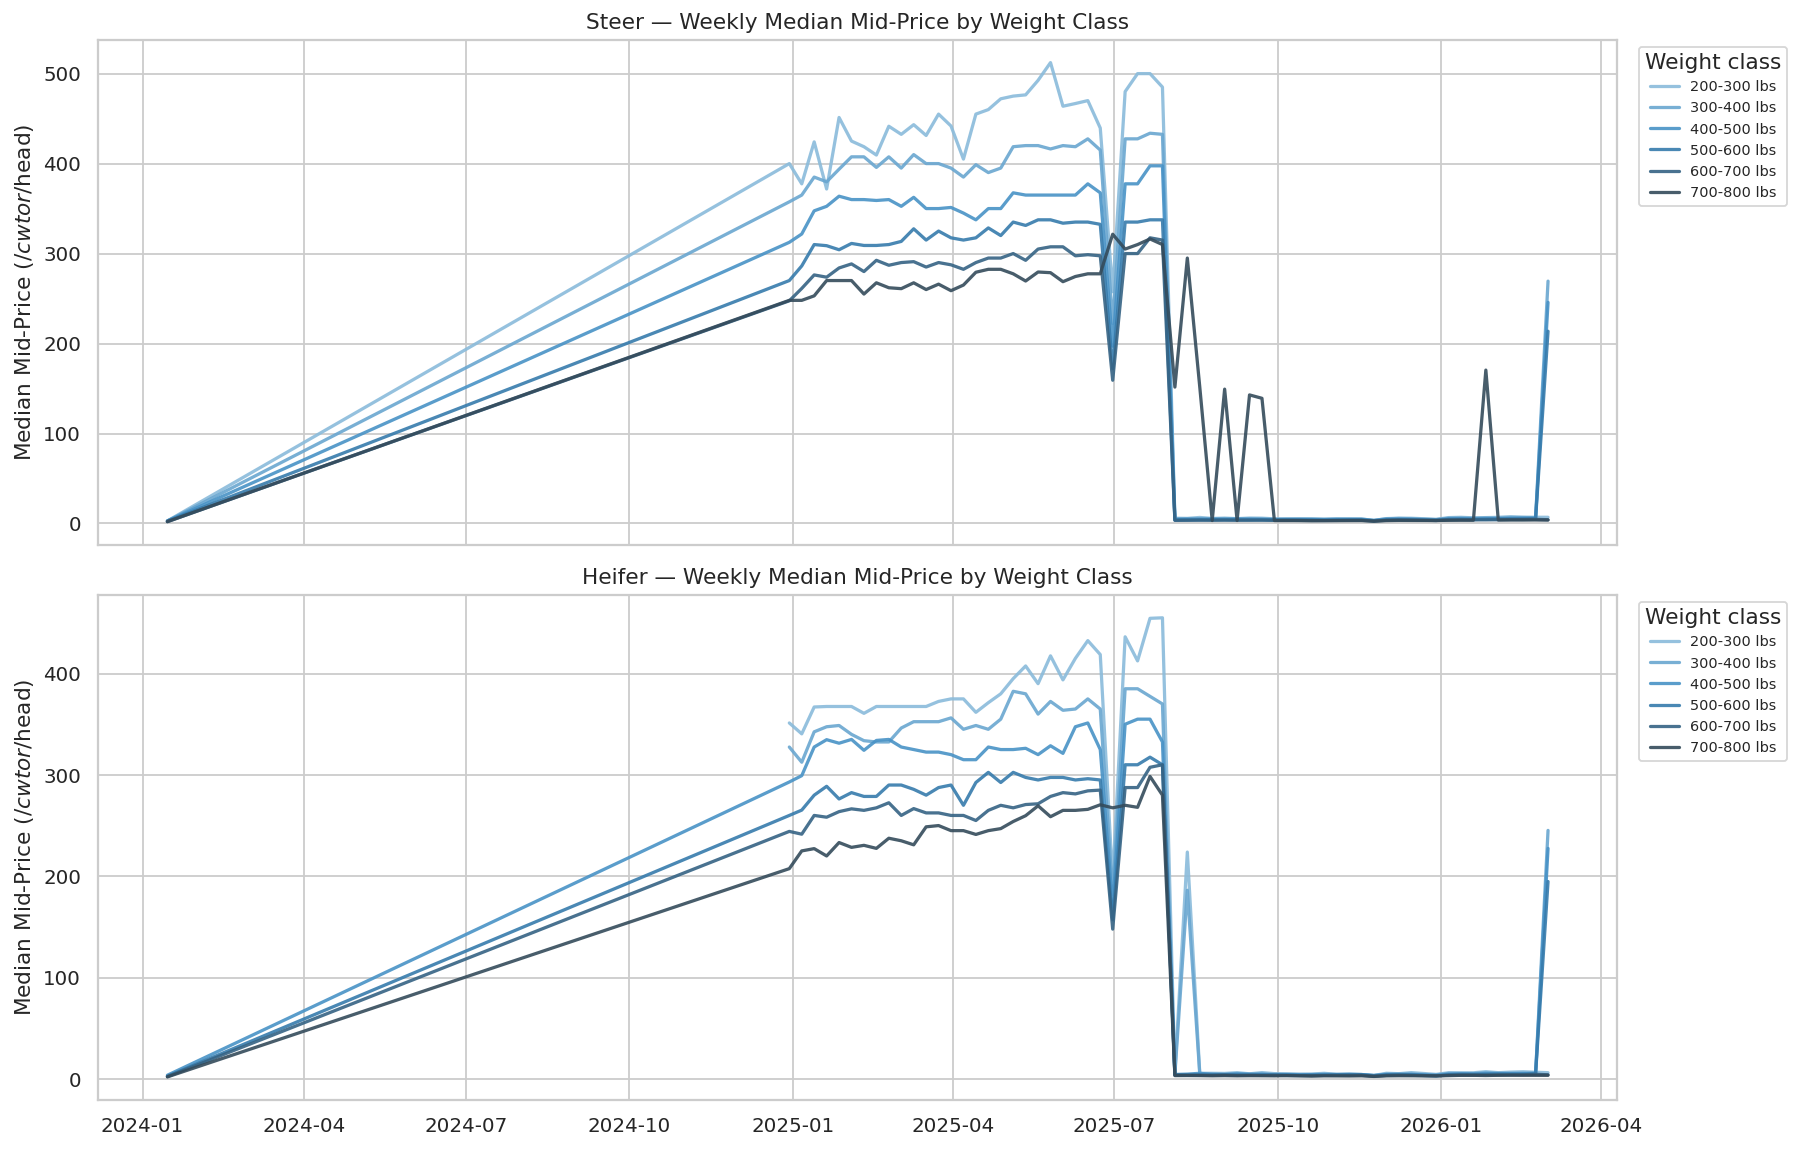

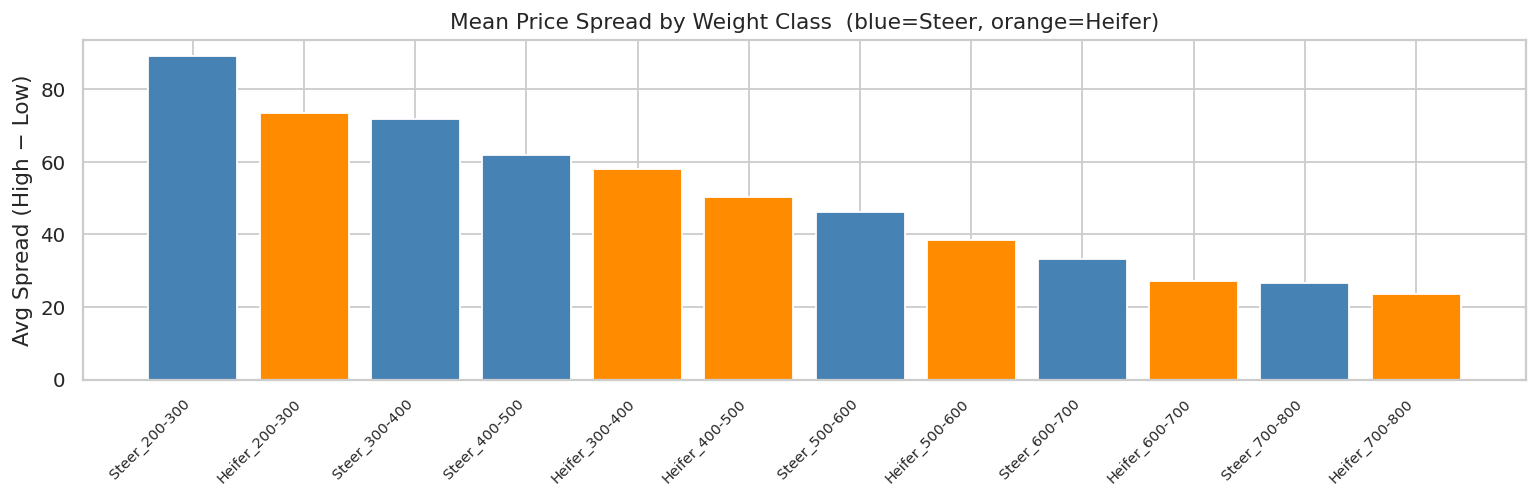

In [5]:
# ── Compute mid-price columns ─────────────────────────────
for df in [all_df, six_df]:
    lows = [c for c in df.columns if c.endswith('_Low')]
    for low_col in lows:
        high_col = low_col.replace('_Low', '_High')
        mid_col  = low_col.replace('_Low', '_Mid')
        if high_col in df.columns:
            df[mid_col] = (df[low_col] + df[high_col]) / 2

price_mid_cols = [c for c in all_df.columns if c.endswith('_Mid')]
steer_mids     = [c for c in price_mid_cols if c.startswith('Steer')]
heifer_mids    = [c for c in price_mid_cols if c.startswith('Heifer')]

# ── 5a. Weekly median price trends (aggregated across barns) ─
all_df['Week'] = all_df['Date'].dt.to_period('W').dt.start_time

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
wc_order = ['200-300','300-400','400-500','500-600','600-700','700-800']
palette5  = sns.color_palette('Blues_d', len(wc_order))

for ax, (cols, title) in zip(axes,
        [(steer_mids,  'Steer — Weekly Median Mid-Price by Weight Class'),
         (heifer_mids, 'Heifer — Weekly Median Mid-Price by Weight Class')]):
    for i, wc in enumerate(wc_order):
        col = next((c for c in cols if wc in c), None)
        if col is None:
            continue
        weekly = all_df.groupby('Week')[col].median().dropna()
        ax.plot(weekly.index, weekly.values,
                label=f'{wc} lbs', linewidth=1.8,
                color=palette5[i], alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel('Median Mid-Price ($/cwt or $/head)')
    ax.legend(title='Weight class', bbox_to_anchor=(1.01,1),
              loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# ── 5b. Price spread bar chart ────────────────────────────
spread_pairs = [(c, c.replace('_Low','_High'))
    for c in all_df.columns
    if c.endswith('_Low') and c.replace('_Low','_High') in all_df.columns]
spread_df    = pd.DataFrame({l.replace('_Low',''): all_df[h]-all_df[l]
                              for l,h in spread_pairs})
# Keep only feeder/stocker weight classes for clarity
keep = [c for c in spread_df.columns
        if any(wc in c for wc in wc_order) and ('Steer' in c or 'Heifer' in c)]
mean_spreads = spread_df[keep].mean().sort_values(ascending=False)

colors_spread = ['steelblue' if 'Steer' in c else 'darkorange'
                 for c in mean_spreads.index]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(mean_spreads)), mean_spreads.values,
       color=colors_spread, edgecolor='white')
ax.set_xticks(range(len(mean_spreads)))
ax.set_xticklabels(mean_spreads.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Avg Spread (High − Low)')
ax.set_title('Mean Price Spread by Weight Class  (blue=Steer, orange=Heifer)')
plt.tight_layout()
plt.show()

## Section 6 — Price Comparison Across Barns
> Restricted to SAM-eligible barns (≥26 sale weeks) to keep charts readable.

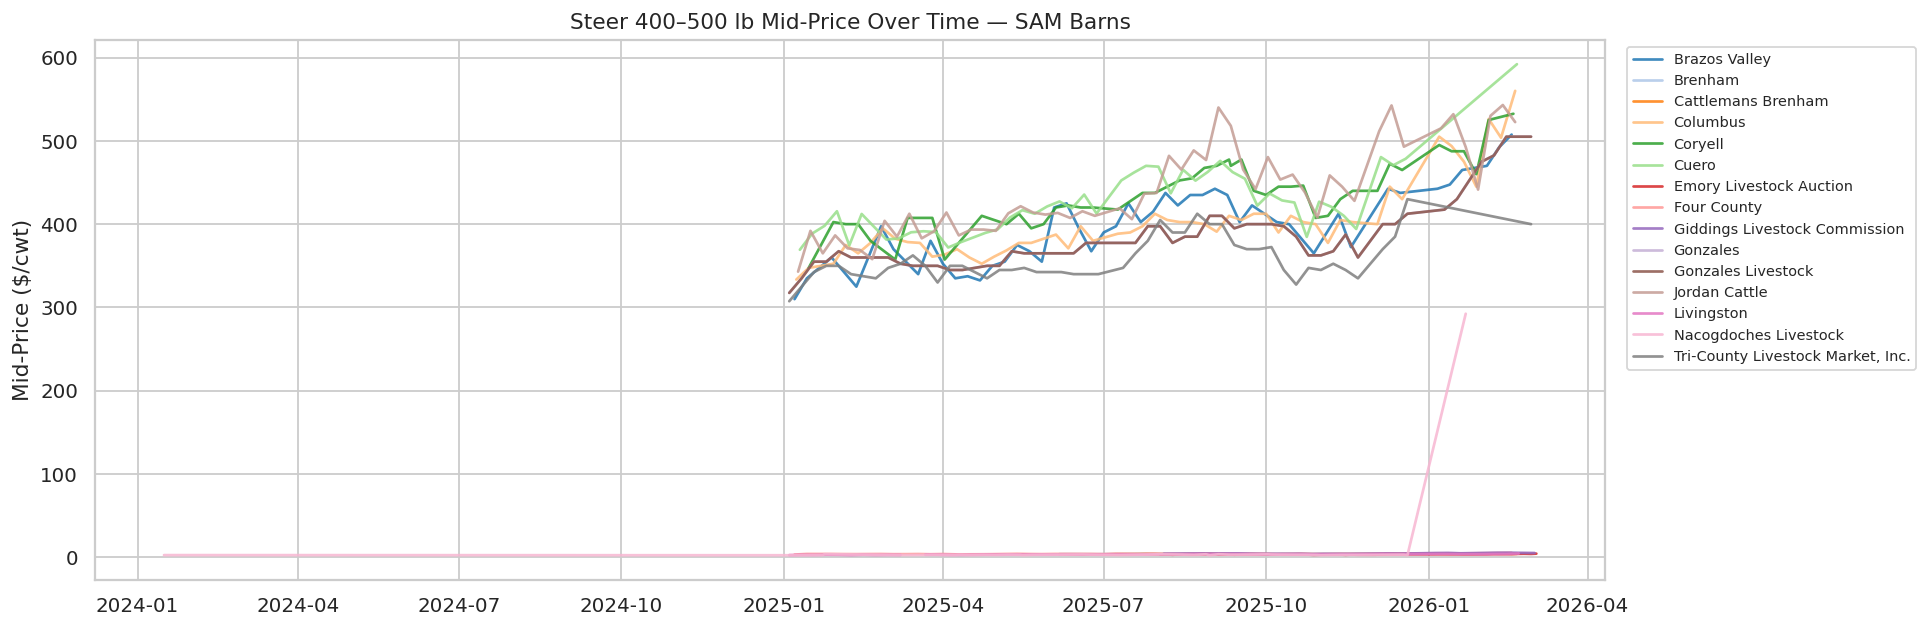

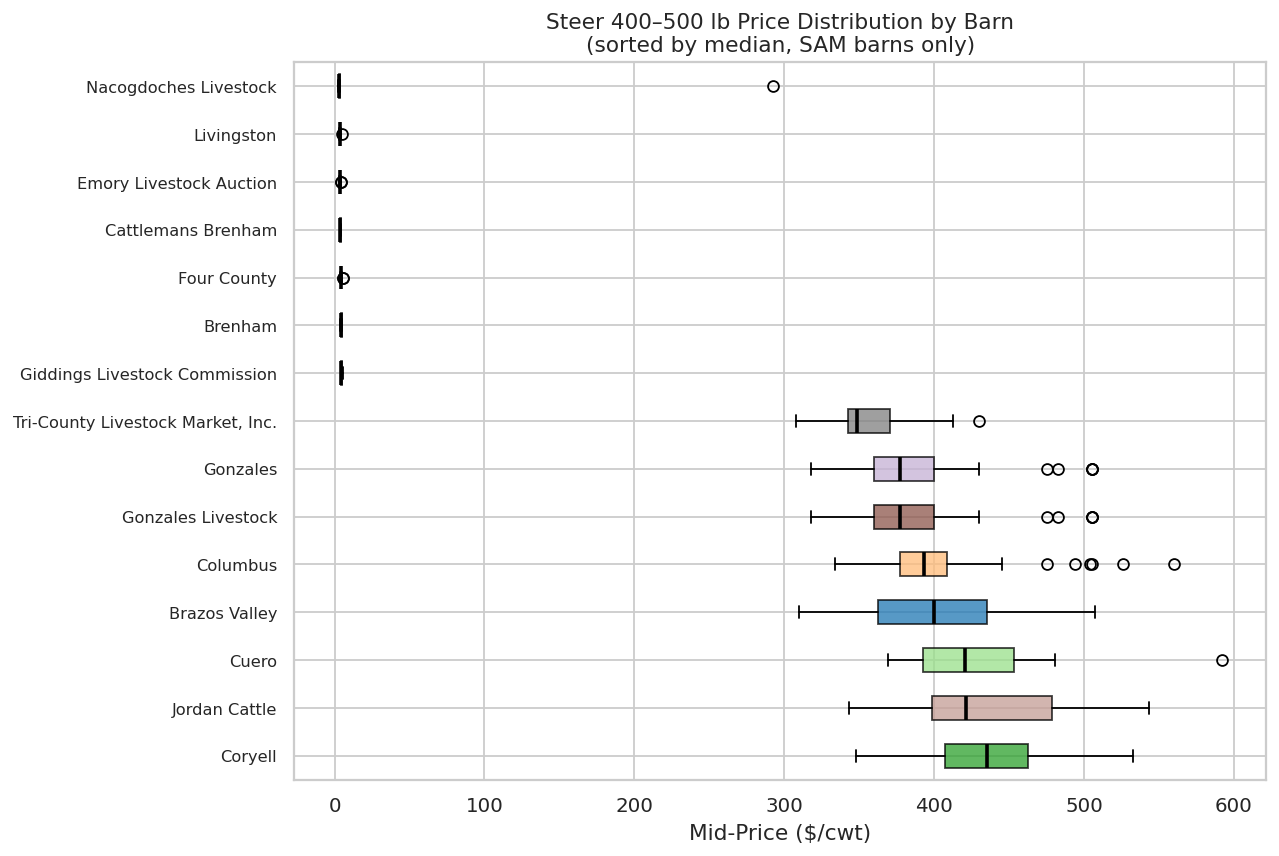

In [6]:
sam_barns_6 = (all_df.groupby('Barn')['Date'].count()[lambda s: s >= 26]).index.tolist()
df6         = all_df[all_df['Barn'].isin(sam_barns_6)].copy()
palette_6   = dict(zip(sam_barns_6, sns.color_palette('tab20', len(sam_barns_6))))

# ── 6a. Line chart: 400-500 Steer mid-price over time ────
col6 = 'Steer_400-500_Mid'
if col6 in df6.columns:
    fig, ax = plt.subplots(figsize=(15, 5))
    for barn in sam_barns_6:
        g = df6[df6['Barn']==barn].sort_values('Date')
        if g[col6].notna().sum() < 3:
            continue
        ax.plot(g['Date'], g[col6], label=barn,
                linewidth=1.5, alpha=0.85, color=palette_6[barn])
    ax.set_title('Steer 400–500 lb Mid-Price Over Time — SAM Barns')
    ax.set_ylabel('Mid-Price ($/cwt)')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
              fontsize=8, ncol=1, frameon=True)
    plt.tight_layout()
    plt.show()

# ── 6b. Box plots: one box per barn, horizontal for readability ──
if col6 in df6.columns:
    barn_order = (df6.groupby('Barn')[col6].median()
                     .dropna().sort_values(ascending=False).index.tolist())
    data_to_plot = [df6[df6['Barn']==b][col6].dropna().values for b in barn_order]
    colors_bp = [palette_6.get(b, 'gray') for b in barn_order]

    fig, ax = plt.subplots(figsize=(10, max(5, len(barn_order)*0.45)))
    bp = ax.boxplot(data_to_plot, vert=False, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)
    ax.set_yticks(range(1, len(barn_order)+1))
    ax.set_yticklabels(barn_order, fontsize=9)
    ax.set_xlabel('Mid-Price ($/cwt)')
    ax.set_title('Steer 400–500 lb Price Distribution by Barn\n(sorted by median, SAM barns only)')
    plt.tight_layout()
    plt.show()

## Section 7 — Sale Frequency & Calendar Patterns

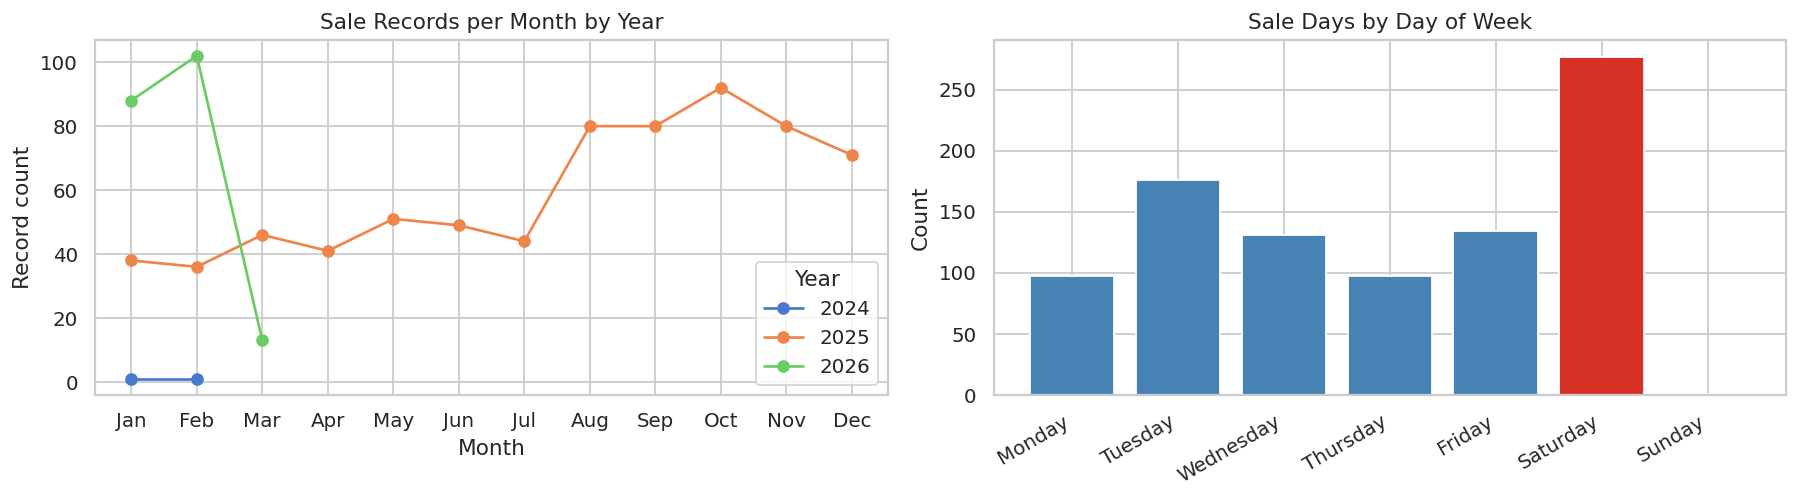

Red bar = Saturday (dominant sale day as expected for cattle auctions)


In [7]:
all_df['Year']      = all_df['Date'].dt.year
all_df['Month']     = all_df['Date'].dt.month
all_df['DayOfWeek'] = all_df['Date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sale records per month
sales_pm = all_df.groupby(['Year','Month'])['Barn'].count().unstack(0)
sales_pm.plot(ax=axes[0], marker='o', linewidth=1.5)
axes[0].set_title('Sale Records per Month by Year')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Record count')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].legend(title='Year')

# Day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = all_df['DayOfWeek'].value_counts().reindex(dow_order)
bar_colors = ['#d73027' if d == 'Saturday' else 'steelblue' for d in dow_order]
axes[1].bar(dow_order, dow_counts.values, color=bar_colors, edgecolor='white')
axes[1].set_title('Sale Days by Day of Week')
axes[1].set_ylabel('Count')
for tick in axes[1].get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha('right')

plt.tight_layout()
plt.show()
print("Red bar = Saturday (dominant sale day as expected for cattle auctions)")

## Section 8 — Six-Month Barn Extra Categories

=== Price Unit Mix (six_month_barns) ===


Price_Unit,$/cwt,$/head
Barn,,
Brenham,0,30
Columbus,0,54
Coryell,0,47
Cuero,0,47
Four County,0,54
Gonzales,0,55
Livingston,54,0


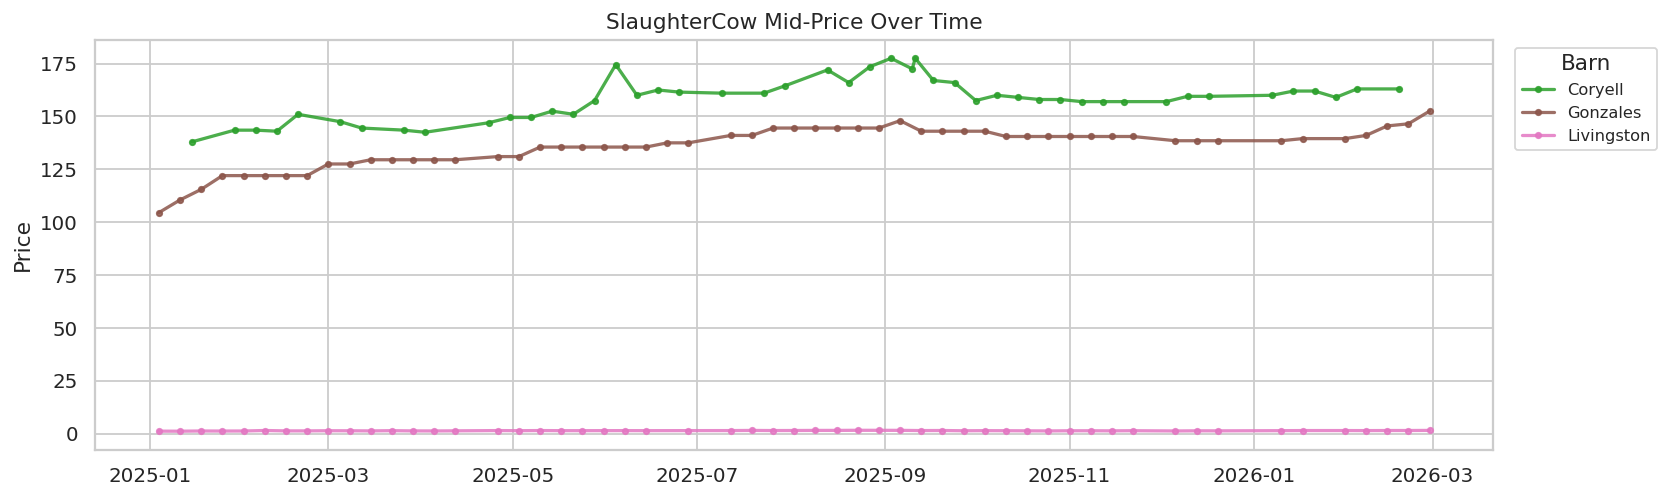

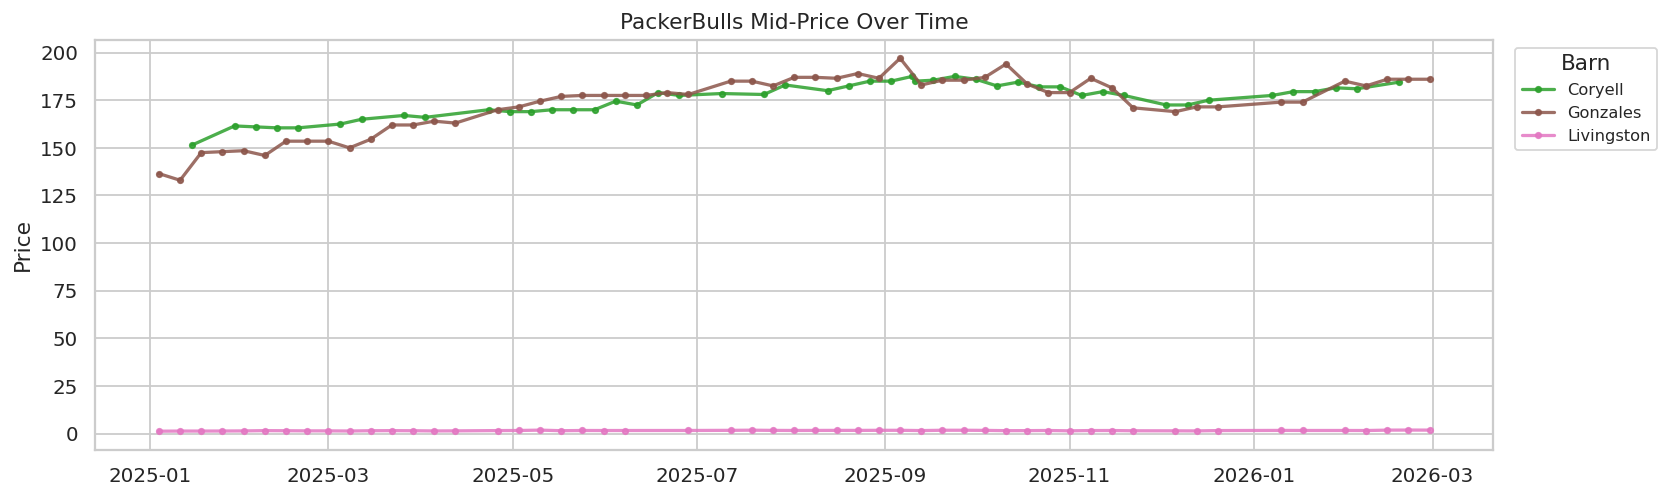

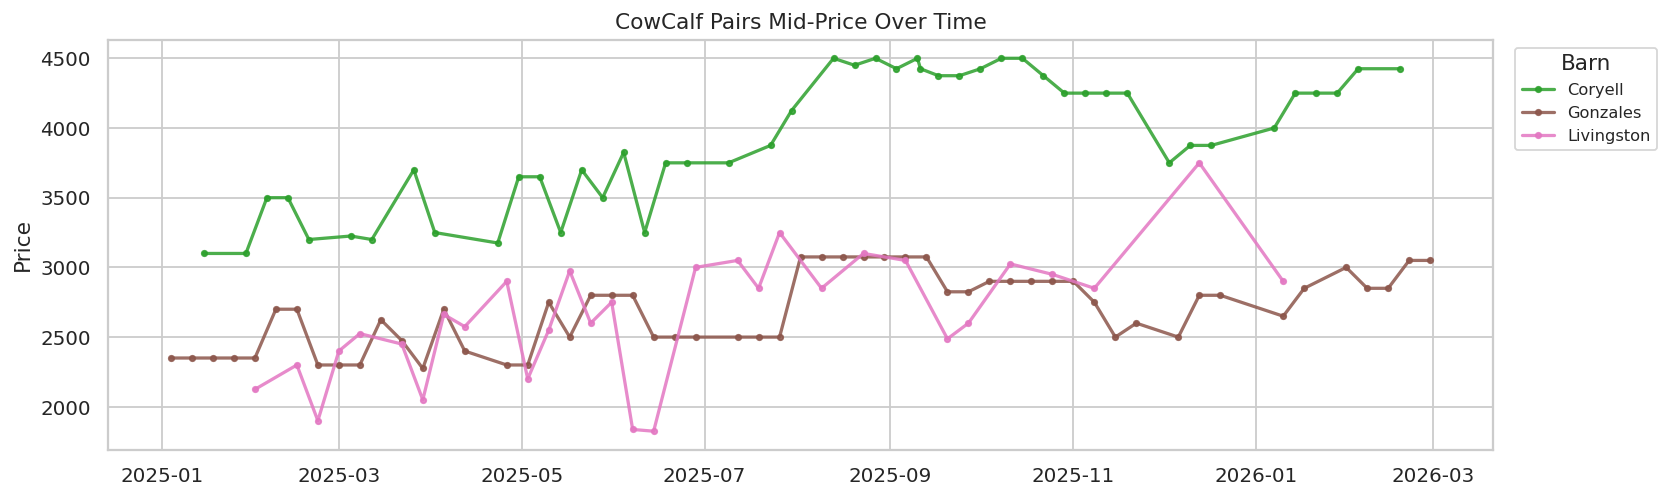

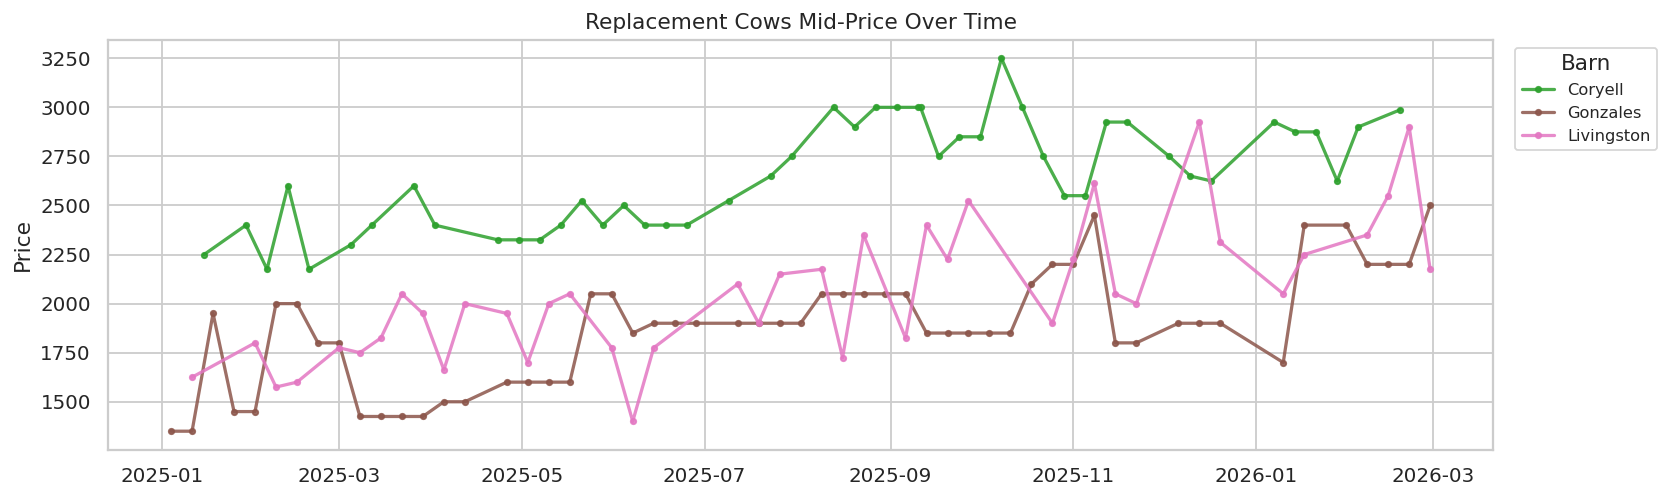

In [8]:
if 'Price_Unit' in six_df.columns:
    print("=== Price Unit Mix (six_month_barns) ===")
    display(six_df.groupby(['Barn','Price_Unit']).size().unstack(fill_value=0))

extra_cats = ['SlaughterCow','PackerBulls','CowCalf_Pairs','Replacement_Cows']
six_mid_cols = [c for c in six_df.columns if c.endswith('_Mid')]

# One clean subplot per category
for cat in extra_cats:
    cat_cols = [c for c in six_mid_cols if c.startswith(cat)]
    if not cat_cols:
        continue

    barns_8  = sorted(six_df['Barn'].dropna().unique())
    pal_8    = sns.color_palette('tab10', len(barns_8))
    col_map  = dict(zip(barns_8, pal_8))

    fig, ax = plt.subplots(figsize=(13, 4))
    for barn in barns_8:
        grp = six_df[six_df['Barn']==barn].sort_values('Date')
        # Use the first (or only) col per cat per barn
        col = cat_cols[0]
        series = grp[col].dropna()
        if series.empty:
            continue
        ax.plot(grp.loc[series.index, 'Date'], series.values,
                label=barn, linewidth=1.8, alpha=0.85,
                color=col_map[barn], marker='o', markersize=3)

    ax.set_title(f'{cat.replace("_"," ")} Mid-Price Over Time')
    ax.set_ylabel('Price')
    ax.legend(title='Barn', bbox_to_anchor=(1.01,1),
              loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

## Section 9 — Overall Correlation Matrix
> Feeder/stocker weight classes only (200–800 lb) — most relevant to payment volume.

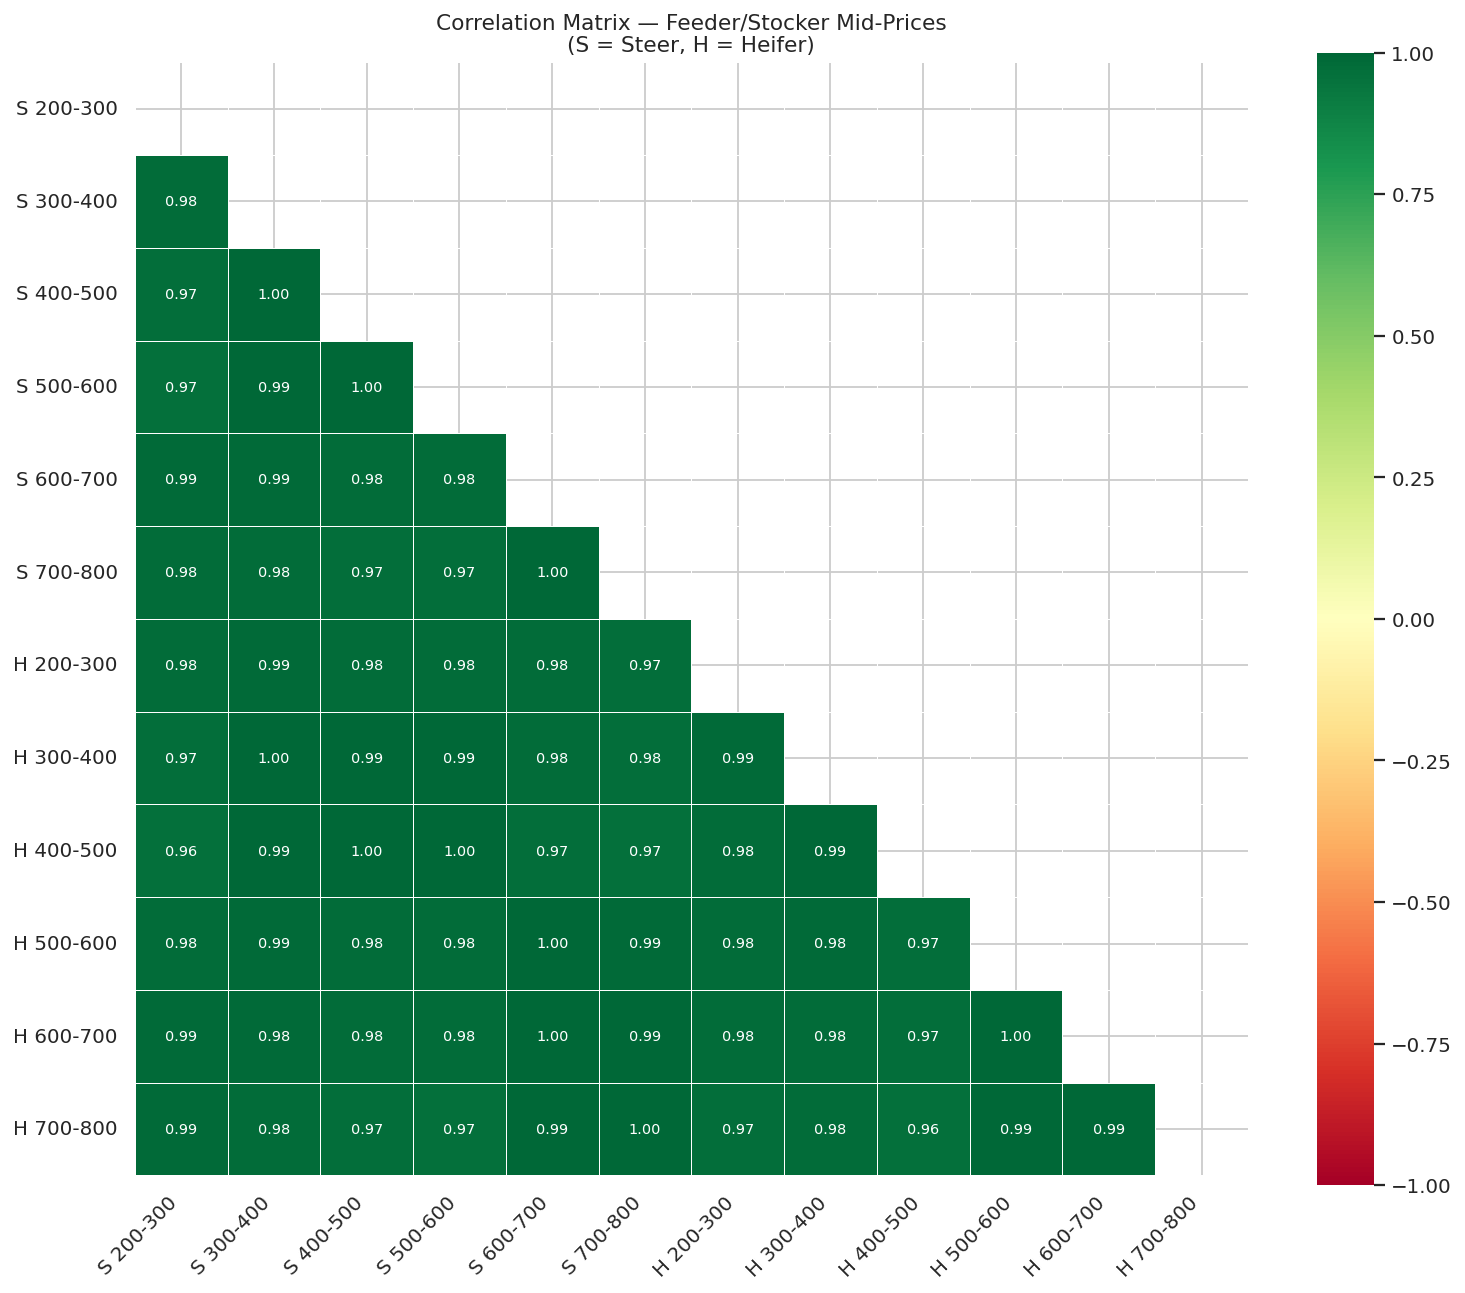


Pairs with |r| ≥ 0.90 : 66
Pairs with |r| ≥ 0.70 : 66
Pairs with |r| < 0.50 : 0


In [9]:
price_mid_cols = [c for c in all_df.columns if c.endswith('_Mid')]

# Focus on the weight classes that have decent data coverage
focus_cols = [c for c in price_mid_cols
              if any(wc in c for wc in ['200-300','300-400','400-500',
                                        '500-600','600-700','700-800'])
              and ('Steer' in c or 'Heifer' in c)]

if focus_cols:
    corr = all_df[focus_cols].corr()
    # Shorter labels for readability
    short_labels = [c.replace('_Mid','').replace('Steer_','S ').replace('Heifer_','H ')
                    for c in focus_cols]

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
    sns.heatmap(corr, ax=ax, mask=mask, cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, annot=True, fmt='.2f',
                xticklabels=short_labels, yticklabels=short_labels,
                linewidths=0.4, square=True, annot_kws={'size':8})
    ax.set_title('Correlation Matrix — Feeder/Stocker Mid-Prices\n(S = Steer, H = Heifer)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # High-correlation summary
    pairs = corr.where(~mask).stack()
    print(f"\nPairs with |r| ≥ 0.90 : {(pairs.abs()>=0.90).sum()}")
    print(f"Pairs with |r| ≥ 0.70 : {(pairs.abs()>=0.70).sum()}")
    print(f"Pairs with |r| < 0.50 : {(pairs.abs()<0.50).sum()}")

## Section 10 — Steer vs Heifer Price Differential

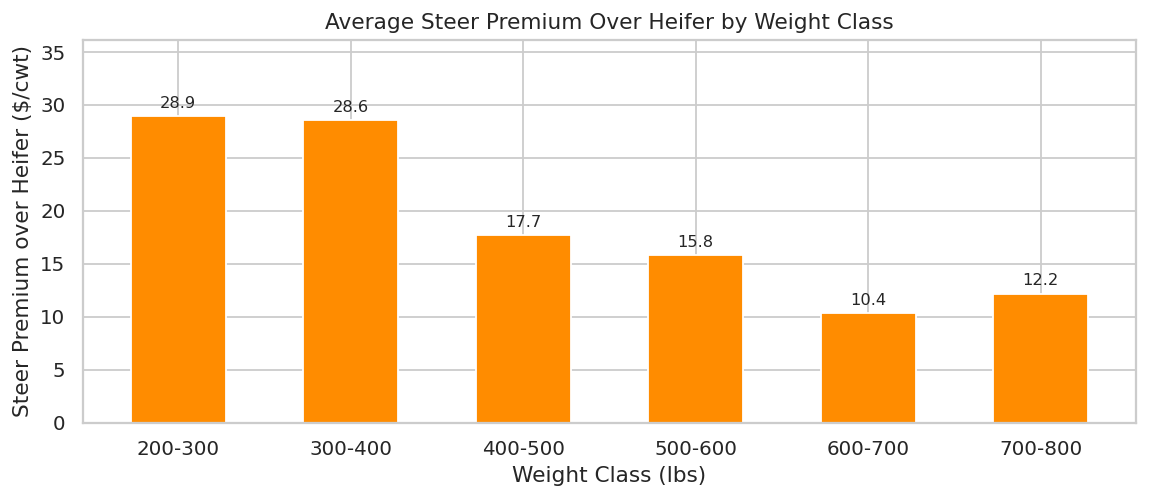

200-300   28.92
300-400   28.56
400-500   17.70
500-600   15.81
600-700   10.35
700-800   12.18


In [10]:
weight_classes = ['200-300','300-400','400-500','500-600','600-700','700-800']
steer_vs_heifer = {}
for wc in weight_classes:
    s_col, h_col = f'Steer_{wc}_Mid', f'Heifer_{wc}_Mid'
    if s_col in all_df.columns and h_col in all_df.columns:
        steer_vs_heifer[wc] = (all_df[s_col] - all_df[h_col]).dropna().mean()

sv_df = pd.Series(steer_vs_heifer, name='Avg Premium ($/cwt)')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(sv_df.index, sv_df.values,
              color='darkorange', edgecolor='white', width=0.55)
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.set_xlabel('Weight Class (lbs)')
ax.set_ylabel('Steer Premium over Heifer ($/cwt)')
ax.set_title('Average Steer Premium Over Heifer by Weight Class')
ax.set_ylim(0, sv_df.max() * 1.25)
plt.tight_layout()
plt.show()
print(sv_df.round(2).to_string())

## Section 11 — B1: Barn Completeness Table *(SAM Gate)*
> Which barns have enough data to be usable in the model?
> Flags barns with **≥26 sale weeks + head count present** as **in-SAM**.

,sale_weeks,date_min,date_max,weeks_span,has_headcount,usable_cols,pct_coverage,in_SAM
Barn,,,,,,,,
Emory Livestock Auction,55,2025-08-02,2026-03-03,30,1,12,52.20,True
Gonzales Livestock,55,2025-01-04,2026-02-28,60,1,14,60.90,True
Jordan Cattle,55,2025-01-09,2026-02-19,58,1,14,60.90,True
Gonzales,55,2025-01-04,2026-02-28,60,1,16,69.60,True
Columbus,54,2025-01-08,2026-02-19,58,1,12,52.20,True
Four County,54,2025-01-07,2026-02-17,58,1,10,43.50,True
Livingston,53,2025-01-04,2026-02-21,59,0,14,60.90,False
"Tri-County Livestock Market, Inc.",48,2025-01-04,2026-02-28,60,1,17,73.90,True
Brazos Valley,47,2025-01-07,2026-02-17,58,1,15,65.20,True



✅ SAM barns (14 of 45): ['Brazos Valley', 'Brenham', 'Cattlemans Brenham', 'Columbus', 'Coryell', 'Cuero', 'Emory Livestock Auction', 'Four County', 'Giddings Livestock Commission', 'Gonzales', 'Gonzales Livestock', 'Jordan Cattle', 'Nacogdoches Livestock', 'Tri-County Livestock Market, Inc.']


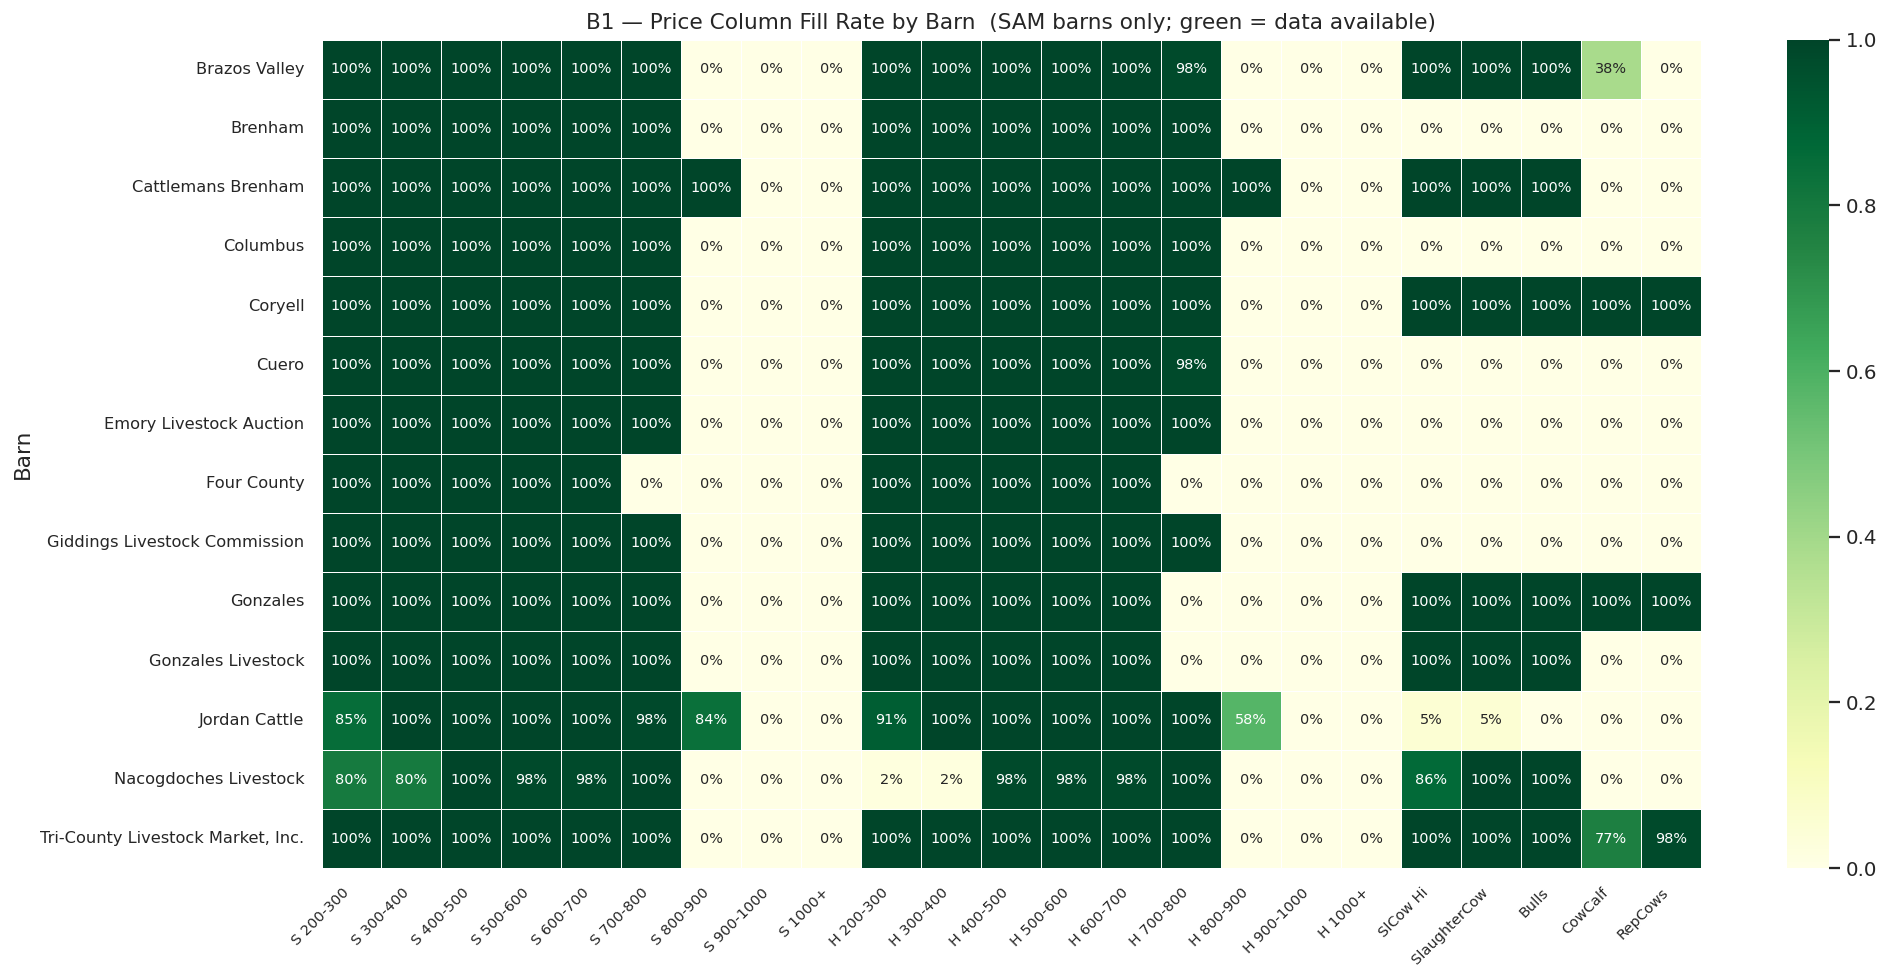

In [11]:
price_mid_cols = [c for c in all_df.columns if c.endswith('_Mid')]

completeness_rows = []
for barn, grp in all_df.groupby('Barn'):
    usable = [c for c in price_mid_cols if grp[c].notna().mean() >= 0.5]
    completeness_rows.append({
        'Barn':            barn,
        'sale_weeks':      len(grp),
        'date_min':        grp['Date'].min().date(),
        'date_max':        grp['Date'].max().date(),
        'weeks_span':      (grp['Date'].max()-grp['Date'].min()).days//7,
        'has_headcount':   int(grp['Head_Count'].notna().mean() >= 0.5),
        'usable_cols':     len(usable),
        'pct_coverage':    round(len(usable)/max(len(price_mid_cols),1)*100,1),
    })

completeness_df = pd.DataFrame(completeness_rows).set_index('Barn')
completeness_df['in_SAM'] = ((completeness_df['sale_weeks']>=26) &
                              (completeness_df['has_headcount']==1))
display(completeness_df.sort_values('sale_weeks', ascending=False))

sam_barns = completeness_df[completeness_df['in_SAM']].index.tolist()
print(f"\n✅ SAM barns ({len(sam_barns)} of {len(completeness_df)}): {sam_barns}")

# ── Fill-rate heatmap: barn × price column (SAM barns only for readability) ──
fill_rate = (all_df[all_df['Barn'].isin(sam_barns)]
             .groupby('Barn')[price_mid_cols]
             .apply(lambda g: g.notna().mean()))
# Shorten column labels
fill_rate.columns = [c.replace('_Mid','').replace('Steer_','S ').replace('Heifer_','H ')
                     .replace('SlaughterCow_High','SlCow Hi').replace('SlaughterCow_Low','SlCow Lo')
                     .replace('PackerBulls','Bulls').replace('CowCalf_Pairs','CowCalf')
                     .replace('Replacement_Cows','RepCows') for c in fill_rate.columns]

fig, ax = plt.subplots(figsize=(16, max(4, len(fill_rate)*0.55)))
sns.heatmap(fill_rate, ax=ax, cmap='YlGn', vmin=0, vmax=1,
            annot=True, fmt='.0%', linewidths=0.3,
            annot_kws={'size': 8})
ax.set_title('B1 — Price Column Fill Rate by Barn  (SAM barns only; green = data available)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Section 12 — B2: Missing Data per Barn *(Quality Gate)*
> Identifies which barns need imputation before feeding the model.

/tmp/ipykernel_144/1625686862.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isnull().mean())


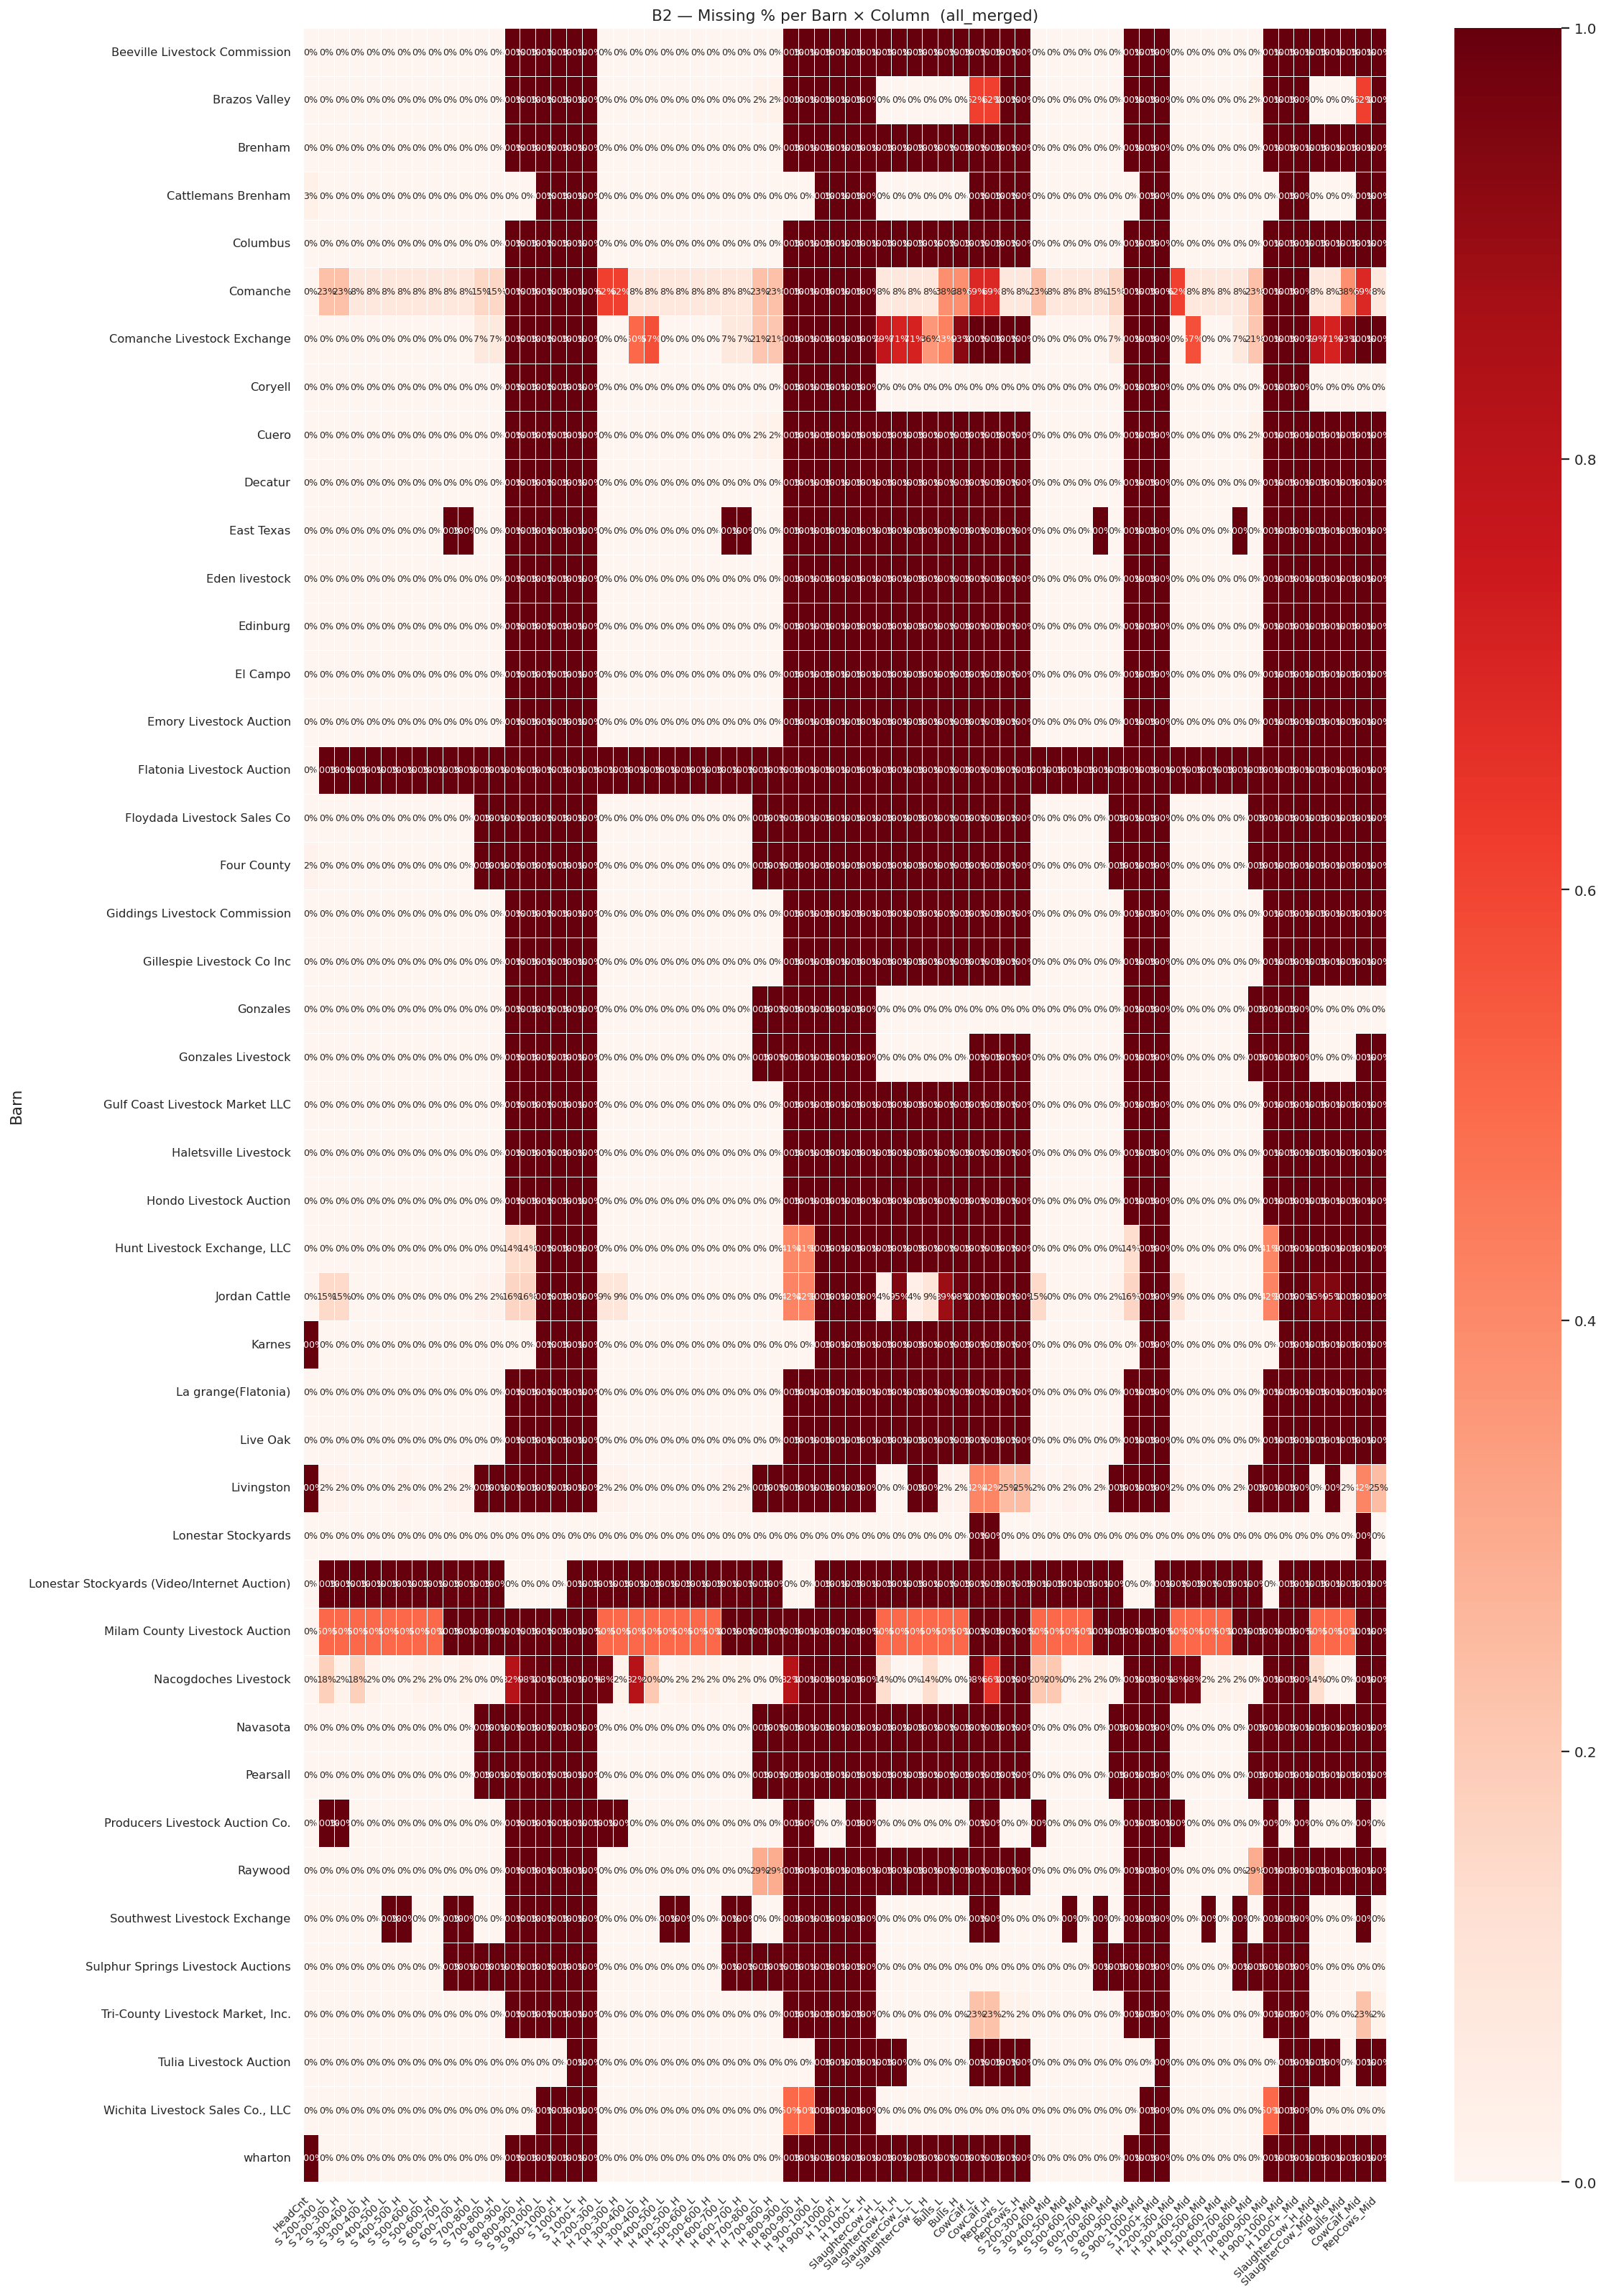

/tmp/ipykernel_144/1625686862.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.isnull().mean())


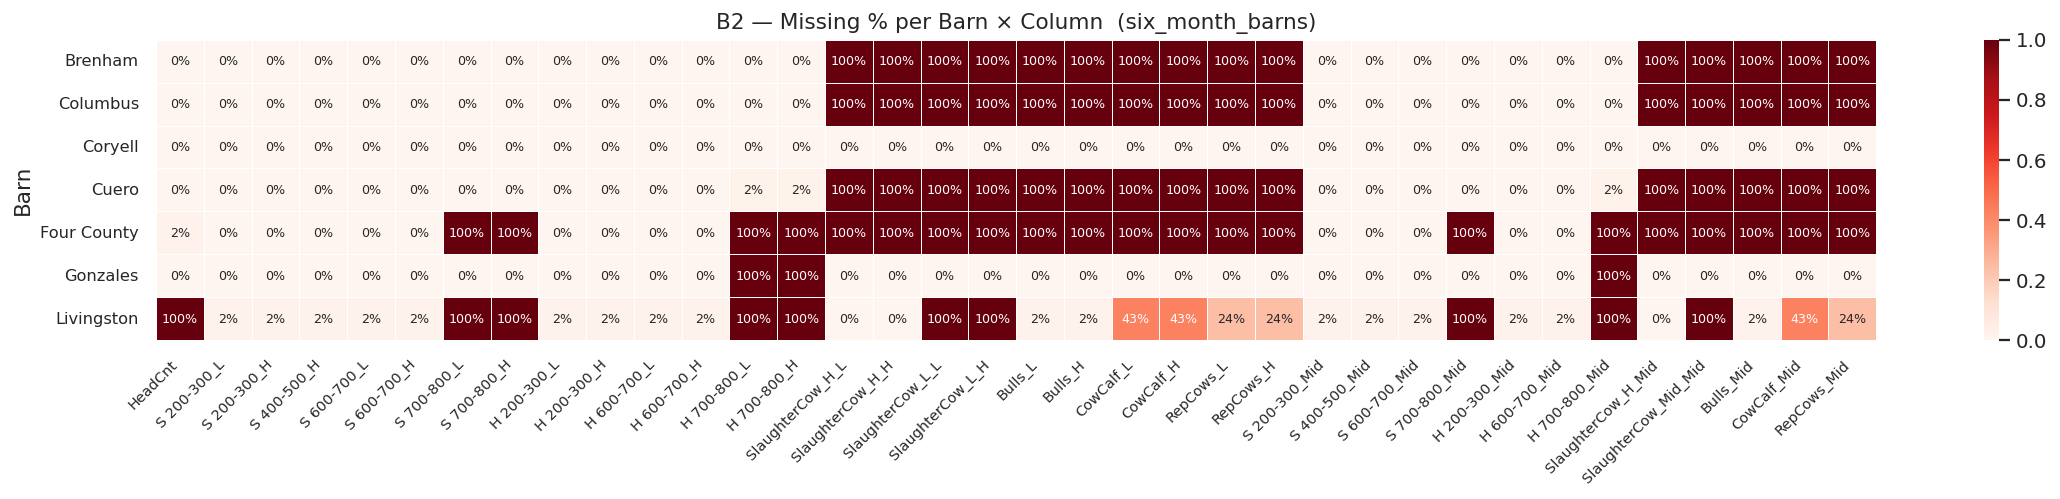

⚠  Barns with <70% price col coverage (need imputation): ['Beeville Livestock Commission', 'Brazos Valley', 'Brenham', 'Columbus', 'Comanche', 'Comanche Livestock Exchange', 'Cuero', 'Decatur', 'East Texas', 'Eden livestock', 'Edinburg', 'El Campo', 'Emory Livestock Auction', 'Flatonia Livestock Auction', 'Floydada Livestock Sales Co', 'Four County', 'Giddings Livestock Commission', 'Gillespie Livestock Co Inc', 'Gonzales', 'Gonzales Livestock', 'Gulf Coast Livestock Market LLC', 'Haletsville Livestock', 'Hondo Livestock Auction', 'Hunt Livestock Exchange, LLC', 'Jordan Cattle', 'Karnes', 'La grange(Flatonia)', 'Live Oak', 'Livingston', 'Lonestar Stockyards (Video/Internet Auction)', 'Milam County Livestock Auction', 'Nacogdoches Livestock', 'Navasota', 'Pearsall', 'Producers Livestock Auction Co.', 'Raywood', 'Southwest Livestock Exchange', 'Sulphur Springs Livestock Auctions', 'Tulia Livestock Auction', 'wharton']


In [12]:
# ── One heatmap per sheet ─────────────────────────────────
for name, df in [("all_merged", all_df), ("six_month_barns", six_df)]:
    barn_miss = (df.groupby('Barn')
                   .apply(lambda g: g.isnull().mean())
                   .drop(columns=['Barn'], errors='ignore'))
    # Keep only columns that are ever missing
    barn_miss = barn_miss[[c for c in barn_miss.columns if barn_miss[c].max() > 0]]
    # Shorten column labels
    barn_miss.columns = [c.replace('_Low','_L').replace('_High','_H')
                          .replace('Steer_','S ').replace('Heifer_','H ')
                          .replace('SlaughterCow_High','SlCow-Hi').replace('SlaughterCow_Low','SlCow-Lo')
                          .replace('PackerBulls','Bulls').replace('CowCalf_Pairs','CowCalf')
                          .replace('Replacement_Cows','RepCows').replace('Head_Count','HeadCnt')
                          for c in barn_miss.columns]

    fig, ax = plt.subplots(figsize=(18, max(4, len(barn_miss)*0.55)))
    sns.heatmap(barn_miss, ax=ax, cmap='Reds', vmin=0, vmax=1,
                annot=True, fmt='.0%', linewidths=0.3,
                annot_kws={'size': 7})
    ax.set_title(f'B2 — Missing % per Barn × Column  ({name})')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

barns_need_impute = completeness_df[completeness_df['pct_coverage'] < 70].index.tolist()
print(f"⚠  Barns with <70% price col coverage (need imputation): {barns_need_impute}")

## Section 13 — B3: Price Distributions by Weight Class *(Price Benchmarks)*
> Sets price benchmarks for per-barn unit economics. One panel per weight class.

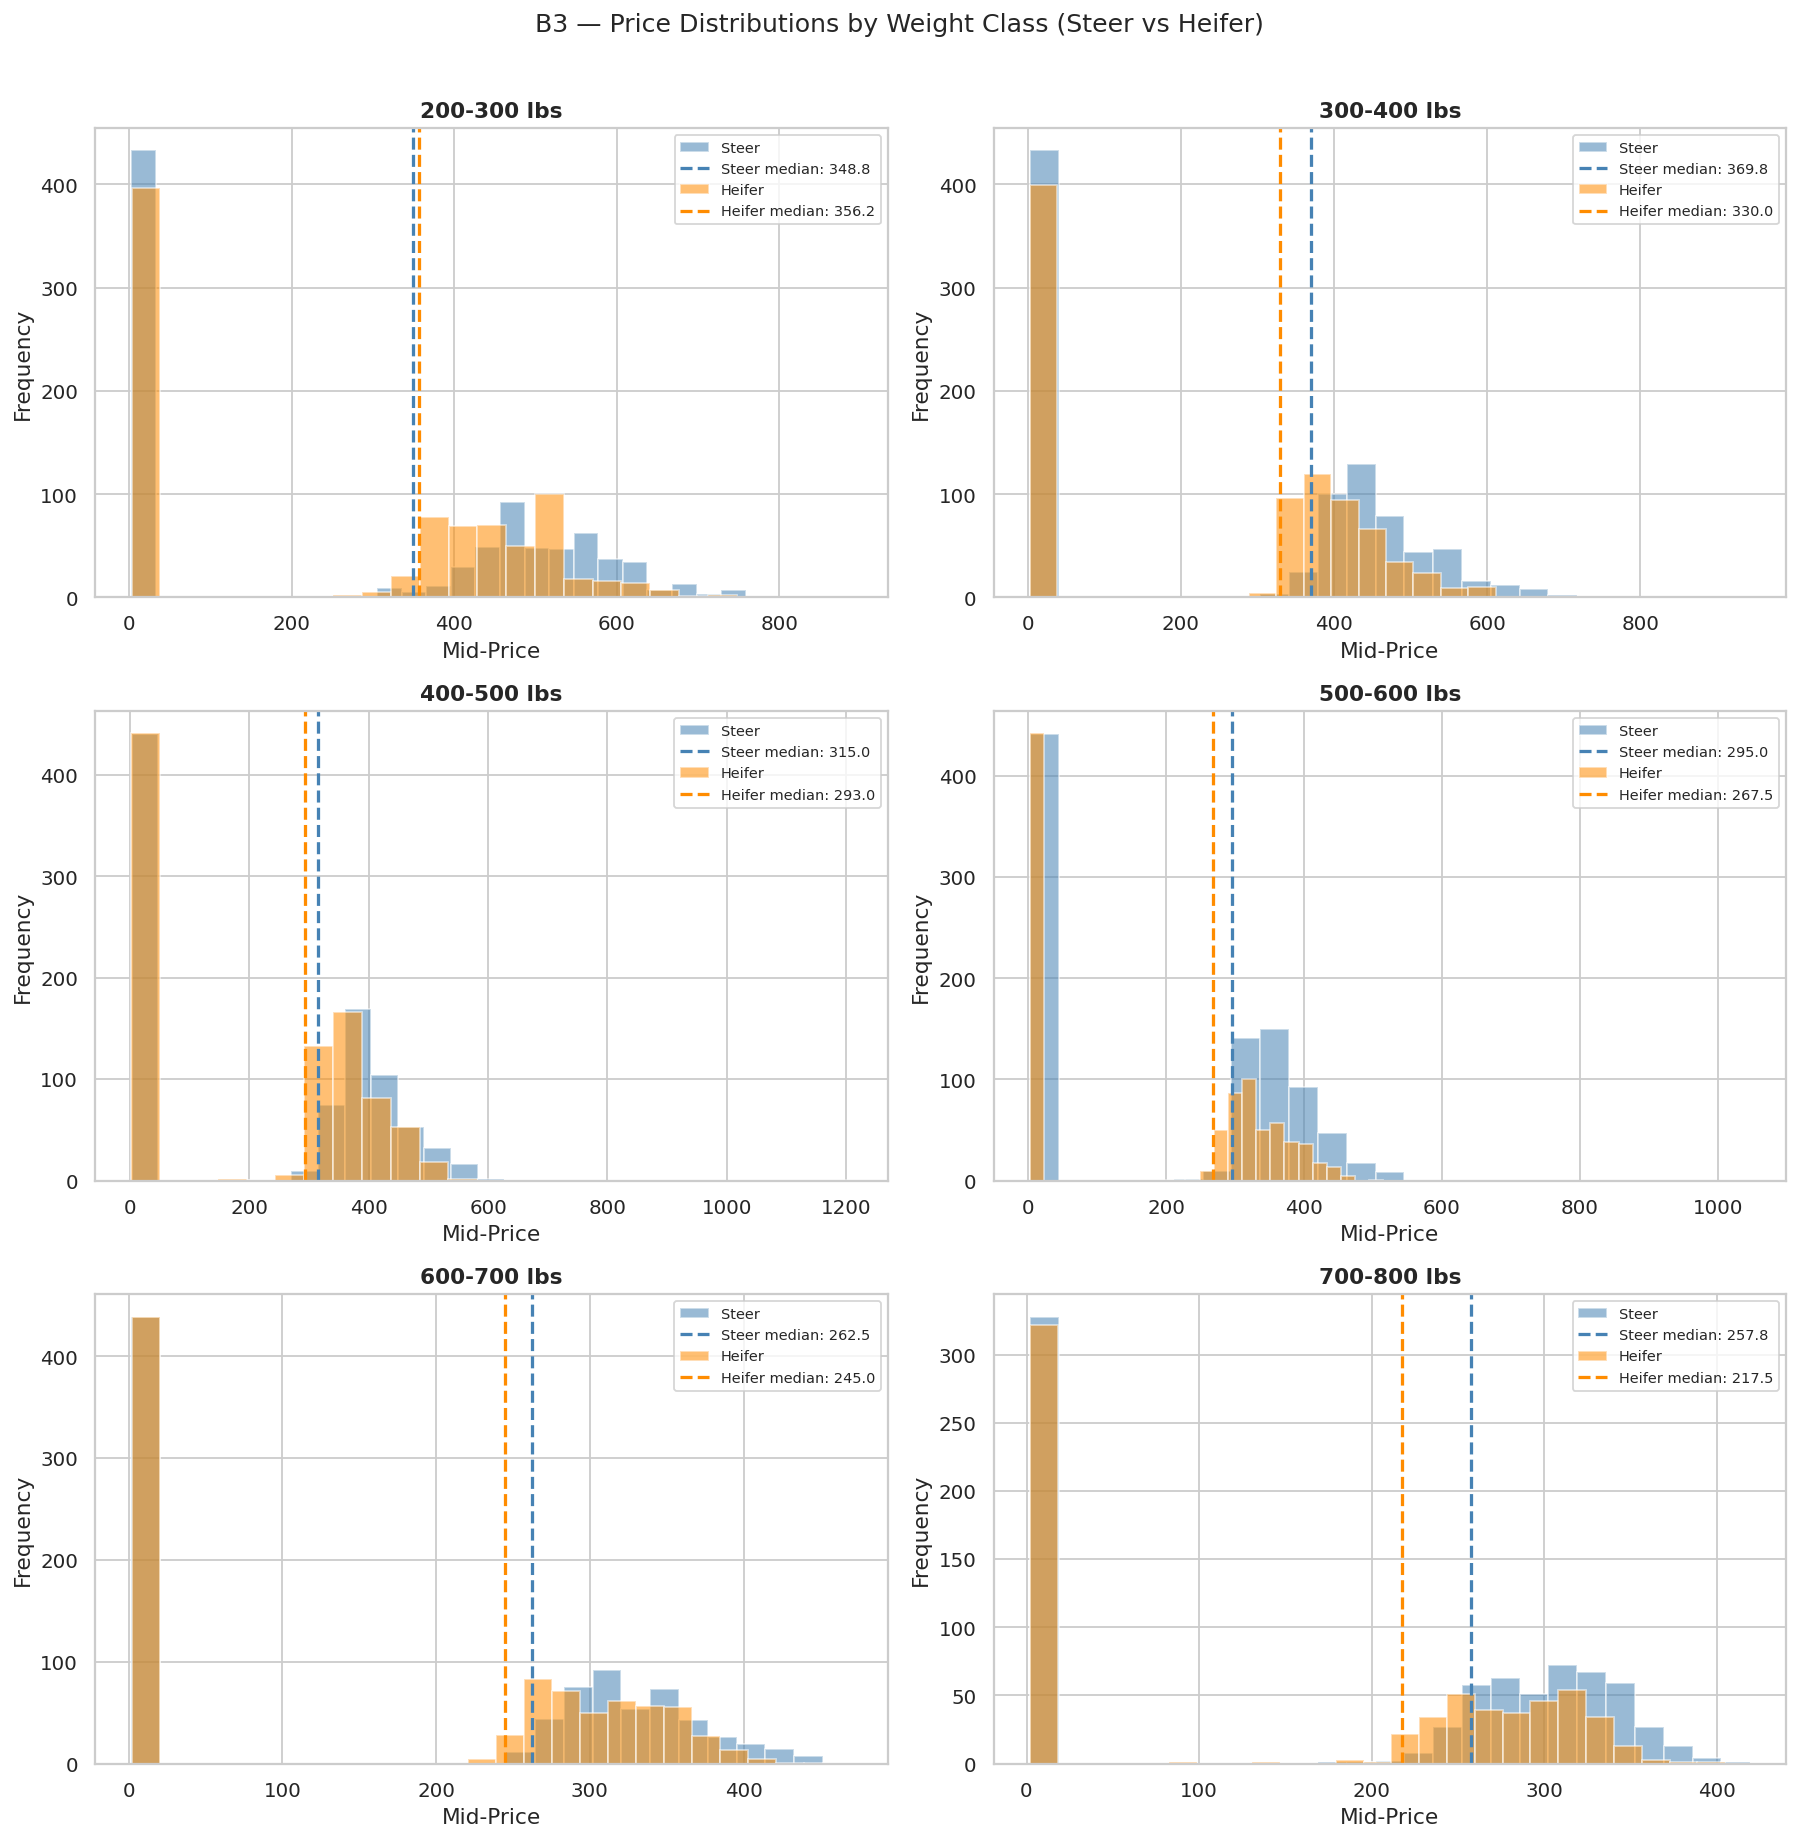


Price Benchmark Table:


,median,mean,p25,p75,n_obs
Steer 200-300,348.75,266.71,4.91,507.50,888.00
Heifer 200-300,356.25,247.57,4.64,460.25,852.00
Steer 300-400,369.75,242.19,4.65,450.00,900.00
Heifer 300-400,330.00,221.93,4.22,405.00,858.00
Steer 400-500,315.00,212.66,4.05,400.00,903.00
Heifer 400-500,293.00,194.66,3.88,365.00,903.00
Steer 500-600,295.00,190.30,3.68,355.44,908.00
Heifer 500-600,267.50,174.49,3.48,325.00,908.00
Steer 600-700,262.50,170.78,3.30,324.75,899.00
Heifer 600-700,245.00,160.32,3.10,310.00,898.00


In [13]:
wc_list = ['200-300','300-400','400-500','500-600','600-700','700-800']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, wc in zip(axes, wc_list):
    s_col = f'Steer_{wc}_Mid'
    h_col = f'Heifer_{wc}_Mid'
    for col, color, label in [(s_col,'steelblue','Steer'),
                               (h_col,'darkorange','Heifer')]:
        if col not in all_df.columns:
            continue
        vals = all_df[col].dropna()
        if vals.empty:
            continue
        ax.hist(vals, bins=25, alpha=0.55, color=color,
                edgecolor='white', label=label)
        ax.axvline(vals.median(), color=color, linestyle='--',
                   linewidth=1.8, label=f'{label} median: {vals.median():.1f}')
    ax.set_title(f'{wc} lbs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mid-Price')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('B3 — Price Distributions by Weight Class (Steer vs Heifer)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Clean summary table
bench = {}
for wc in wc_list:
    for cat in ['Steer','Heifer']:
        col = f'{cat}_{wc}_Mid'
        if col in all_df.columns and all_df[col].notna().sum() > 0:
            bench[f'{cat} {wc}'] = {
                'median': all_df[col].median(),
                'mean':   all_df[col].mean(),
                'p25':    all_df[col].quantile(0.25),
                'p75':    all_df[col].quantile(0.75),
                'n_obs':  int(all_df[col].notna().sum())
            }
bench_df = pd.DataFrame(bench).T.dropna(subset=['median'])
print("\nPrice Benchmark Table:")
display(bench_df.round(2))

## Section 14 — B4: Seasonality Chart *(Imputation Validation)*
> Are prices predictably seasonal? If yes, longer-history barns can proxy short-window barns.

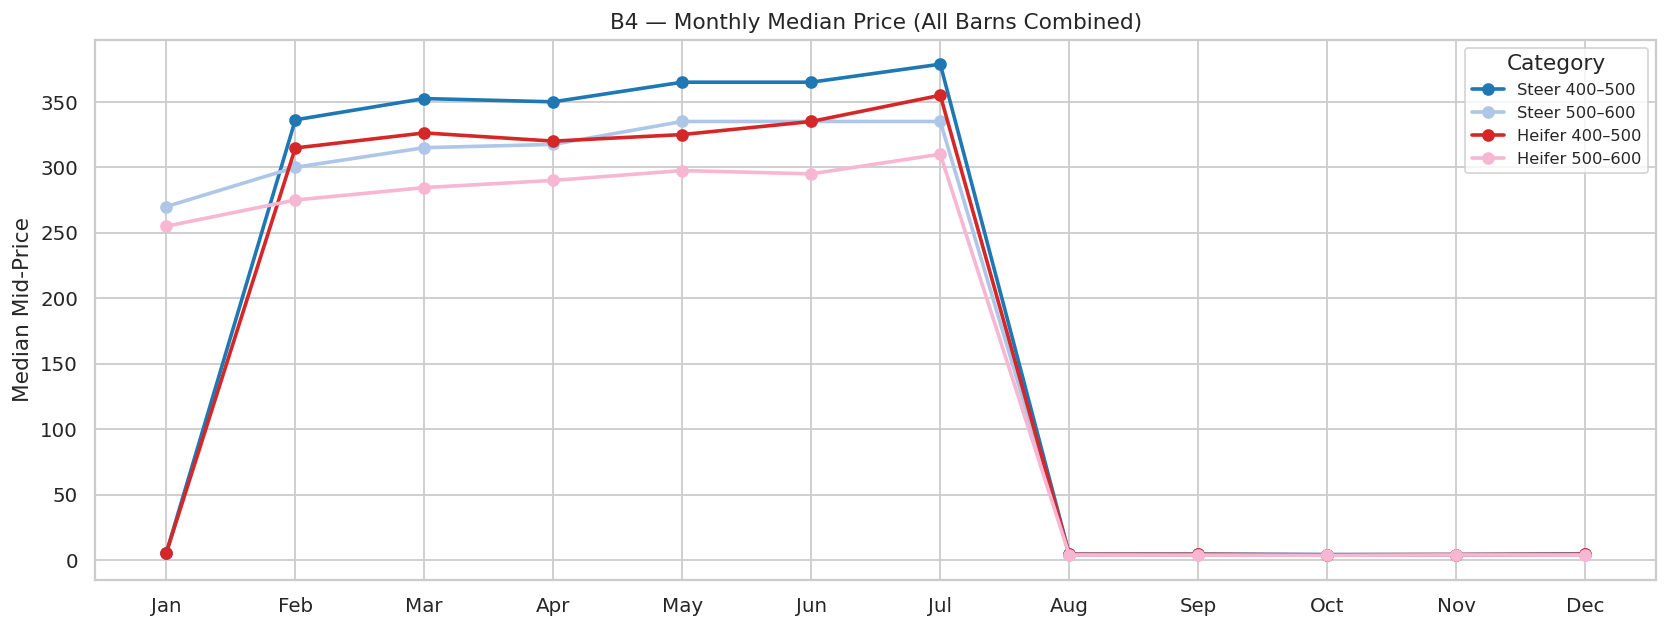

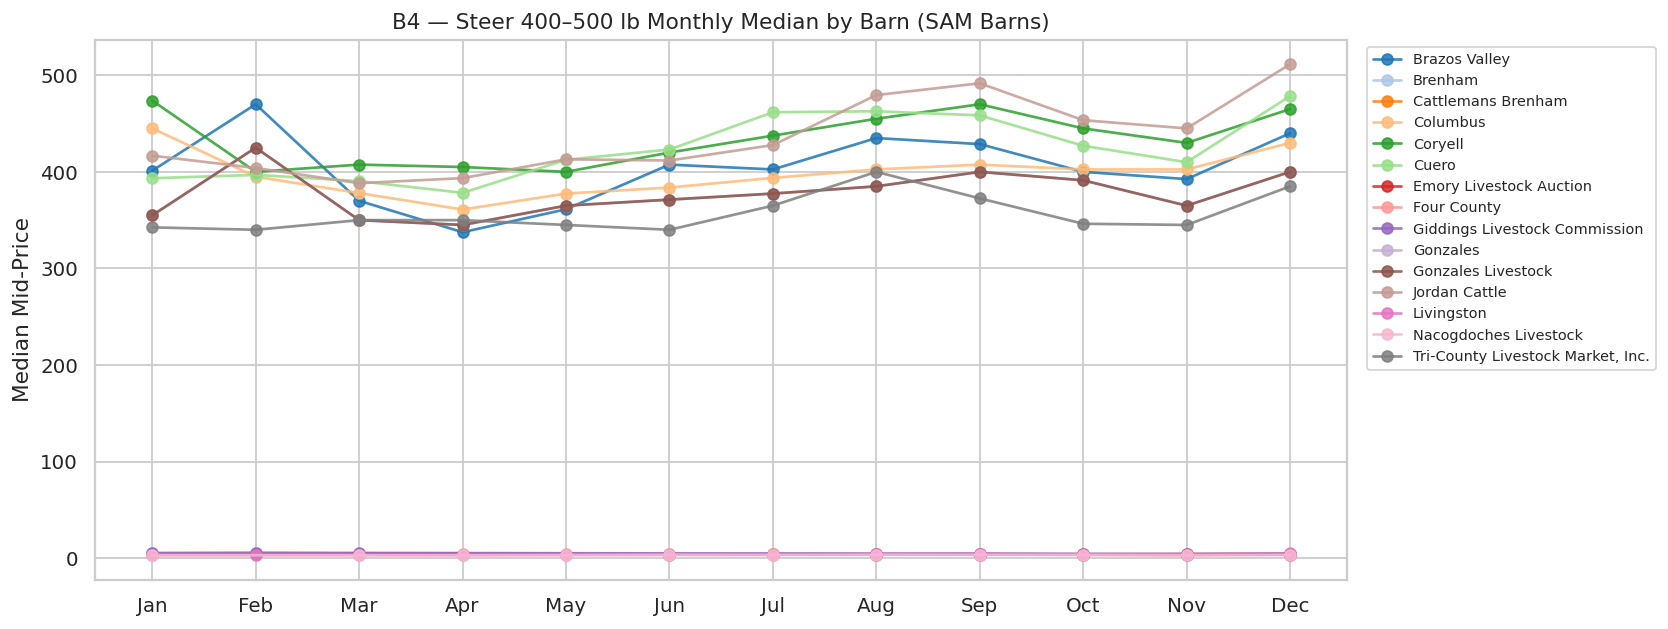

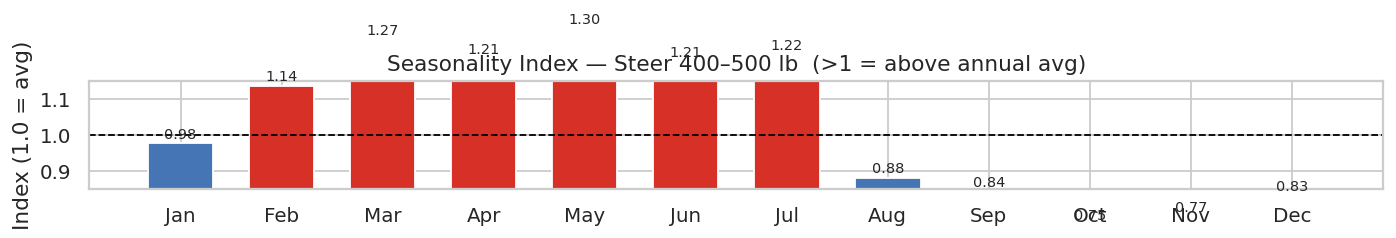

Index range: 0.545 — Strong seasonal pattern


In [14]:
all_df['Month_Num'] = all_df['Date'].dt.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# ── 14a. Monthly median price for 400-500 & 500-600 Steer ─
rep_pairs = [('Steer_400-500_Mid','Steer 400–500'),
             ('Steer_500-600_Mid','Steer 500–600'),
             ('Heifer_400-500_Mid','Heifer 400–500'),
             ('Heifer_500-600_Mid','Heifer 500–600')]

fig, ax = plt.subplots(figsize=(13, 5))
colors14 = ['#1f77b4','#aec7e8','#d62728','#f7b6d2']
for (col, lbl), color in zip(rep_pairs, colors14):
    if col not in all_df.columns:
        continue
    monthly = all_df.groupby('Month_Num')[col].median()
    ax.plot(monthly.index, monthly.values, marker='o', linewidth=2,
            label=lbl, color=color)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('B4 — Monthly Median Price (All Barns Combined)')
ax.set_ylabel('Median Mid-Price')
ax.legend(title='Category', fontsize=9)
plt.tight_layout()
plt.show()

# ── 14b. Per-barn monthly chart (SAM barns) ───────────────
col14 = 'Steer_400-500_Mid'
sam_barns14 = (all_df.groupby('Barn')['Date'].count()[lambda s: s>=26]).index.tolist()
pal14 = dict(zip(sam_barns14, sns.color_palette('tab20', len(sam_barns14))))

fig, ax = plt.subplots(figsize=(13, 5))
for barn in sam_barns14:
    g = all_df[all_df['Barn']==barn]
    monthly = g.groupby('Month_Num')[col14].median()
    if monthly.notna().sum() < 3:
        continue
    ax.plot(monthly.index, monthly.values, marker='o', linewidth=1.5,
            label=barn, alpha=0.85, color=pal14[barn])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title('B4 — Steer 400–500 lb Monthly Median by Barn (SAM Barns)')
ax.set_ylabel('Median Mid-Price')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

# ── 14c. Seasonality index ────────────────────────────────
if col14 in all_df.columns:
    overall_mean = all_df[col14].mean()
    s_idx = all_df.groupby('Month_Num')[col14].mean() / overall_mean
    s_idx.index = month_labels

    fig, ax = plt.subplots(figsize=(11, 3.5))
    colors_idx = ['#d73027' if v > 1.02 else '#4575b4' if v < 0.98 else '#91bfdb'
                  for v in s_idx.values]
    ax.bar(s_idx.index, s_idx.values, color=colors_idx, edgecolor='white', width=0.65)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Seasonality Index — Steer 400–500 lb  (>1 = above annual avg)')
    ax.set_ylabel('Index (1.0 = avg)')
    ax.set_ylim(0.85, 1.15)
    for i, (m, v) in enumerate(zip(s_idx.index, s_idx.values)):
        ax.text(i, v + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()
    idx_range = s_idx.max() - s_idx.min()
    print(f"Index range: {idx_range:.3f} — "
          f"{'Strong seasonal pattern' if idx_range>0.10 else 'Mild seasonality'}")

## Section 15 — B5: Barn-to-Barn Price Correlation *(Key Imputation Test)*
> **The key one.** If most barn pairs have |r| ≥ 0.70, seasonal imputation is defensible.

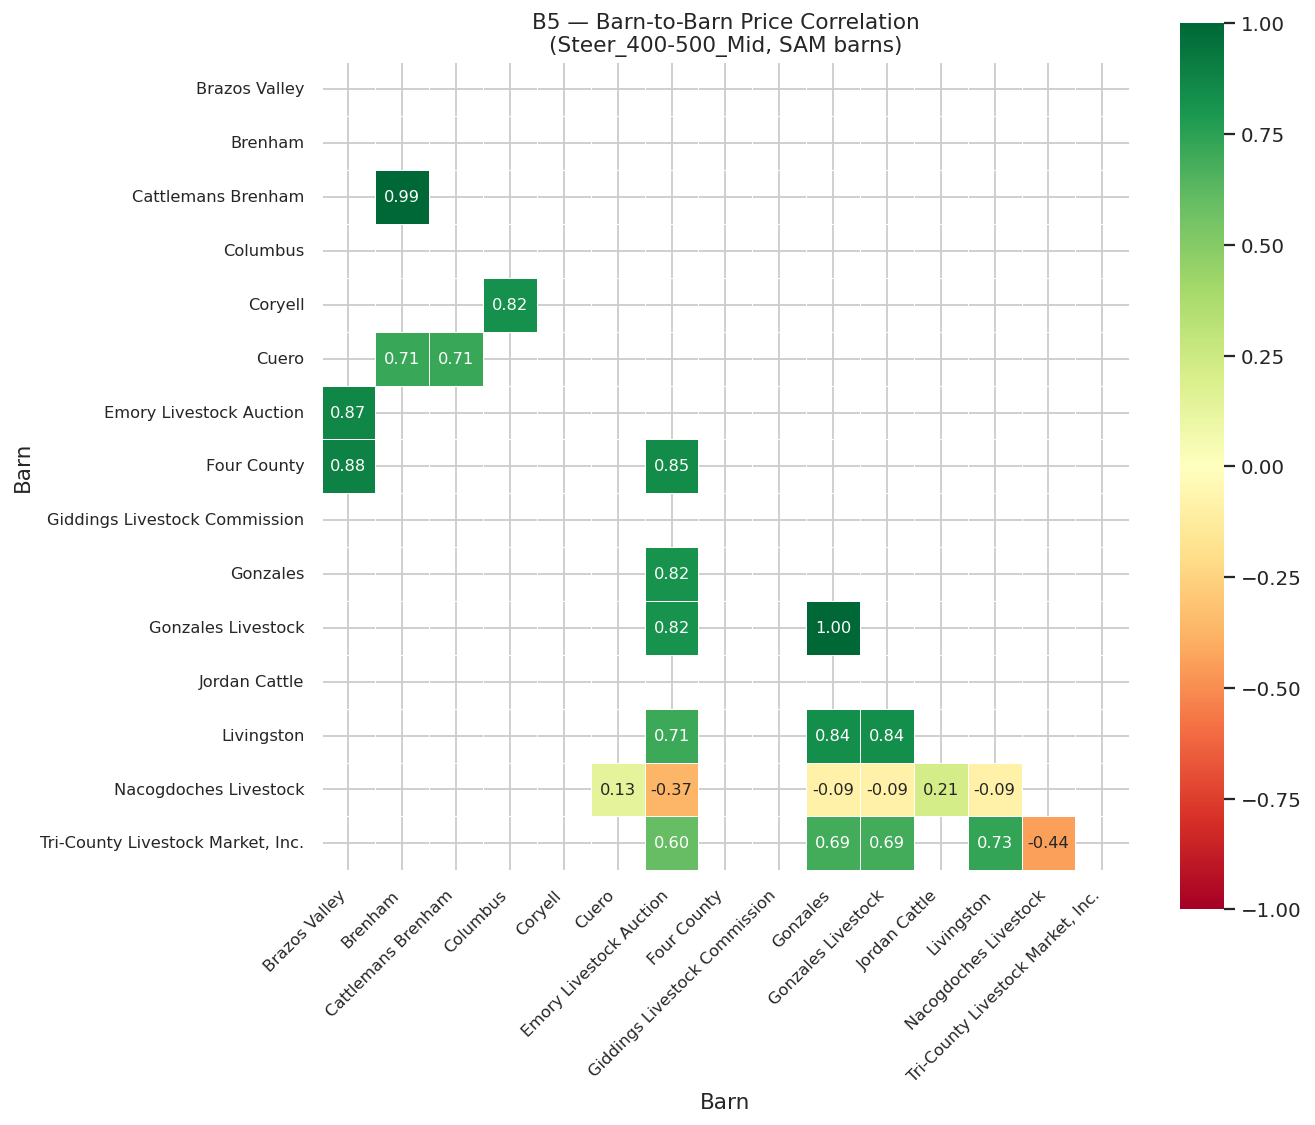


Barn pairs with |r| ≥ 0.70: 58.3%  (14 of 24 pairs)
⚠  Lower inter-barn correlation — validate imputation carefully.

Full correlation matrix:


Barn,Brazos Valley,Brenham,Cattlemans Brenham,Columbus,Coryell,Cuero,Emory Livestock Auction,Four County,Giddings Livestock Commission,Gonzales,Gonzales Livestock,Jordan Cattle,Livingston,Nacogdoches Livestock,"Tri-County Livestock Market, Inc."
Barn,,,,,,,,,,,,,,,
Brazos Valley,1.00,NaN,NaN,NaN,NaN,NaN,0.87,0.88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brenham,NaN,1.00,0.99,NaN,NaN,0.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cattlemans Brenham,NaN,0.99,1.00,NaN,NaN,0.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Columbus,NaN,NaN,NaN,1.00,0.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coryell,NaN,NaN,NaN,0.82,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cuero,NaN,0.71,0.71,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.13,NaN
Emory Livestock Auction,0.87,NaN,NaN,NaN,NaN,NaN,1.00,0.85,NaN,0.82,0.82,NaN,0.71,-0.37,0.60
Four County,0.88,NaN,NaN,NaN,NaN,NaN,0.85,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Giddings Livestock Commission,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
corr_col   = 'Steer_400-500_Mid'
sam_barns5 = (all_df.groupby('Barn')['Date'].count()[lambda s: s>=26]).index.tolist()
df_sam5    = all_df[all_df['Barn'].isin(sam_barns5)]

if corr_col in df_sam5.columns:
    pivot     = df_sam5.pivot_table(index='Date', columns='Barn', values=corr_col)
    barn_corr = pivot.corr()

    # Lower-triangle heatmap with readable font
    mask = np.triu(np.ones_like(barn_corr, dtype=bool))
    n    = len(barn_corr)
    fig, ax = plt.subplots(figsize=(max(8, n*0.7), max(7, n*0.6)))
    sns.heatmap(barn_corr, ax=ax, mask=mask, cmap='RdYlGn',
                center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', linewidths=0.4, square=True,
                annot_kws={'size': 9})
    ax.set_title(f'B5 — Barn-to-Barn Price Correlation\n({corr_col}, SAM barns)')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

    corr_vals     = barn_corr.where(~mask).stack()
    high_pct      = (corr_vals.abs() >= 0.70).mean() * 100
    print(f"\nBarn pairs with |r| ≥ 0.70: {high_pct:.1f}%  ({(corr_vals.abs()>=0.70).sum()} of {len(corr_vals)} pairs)")
    if high_pct >= 70:
        print("✅ High inter-barn correlation — seasonal imputation is DEFENSIBLE.")
    else:
        print("⚠  Lower inter-barn correlation — validate imputation carefully.")
    print("\nFull correlation matrix:")
    display(barn_corr.round(2))

## Section 16 — B6: Cow Volume Over Time *(Transaction Volume Proxy)*
> Head count proxies transaction count → inputs for check volume & payment rail economics.

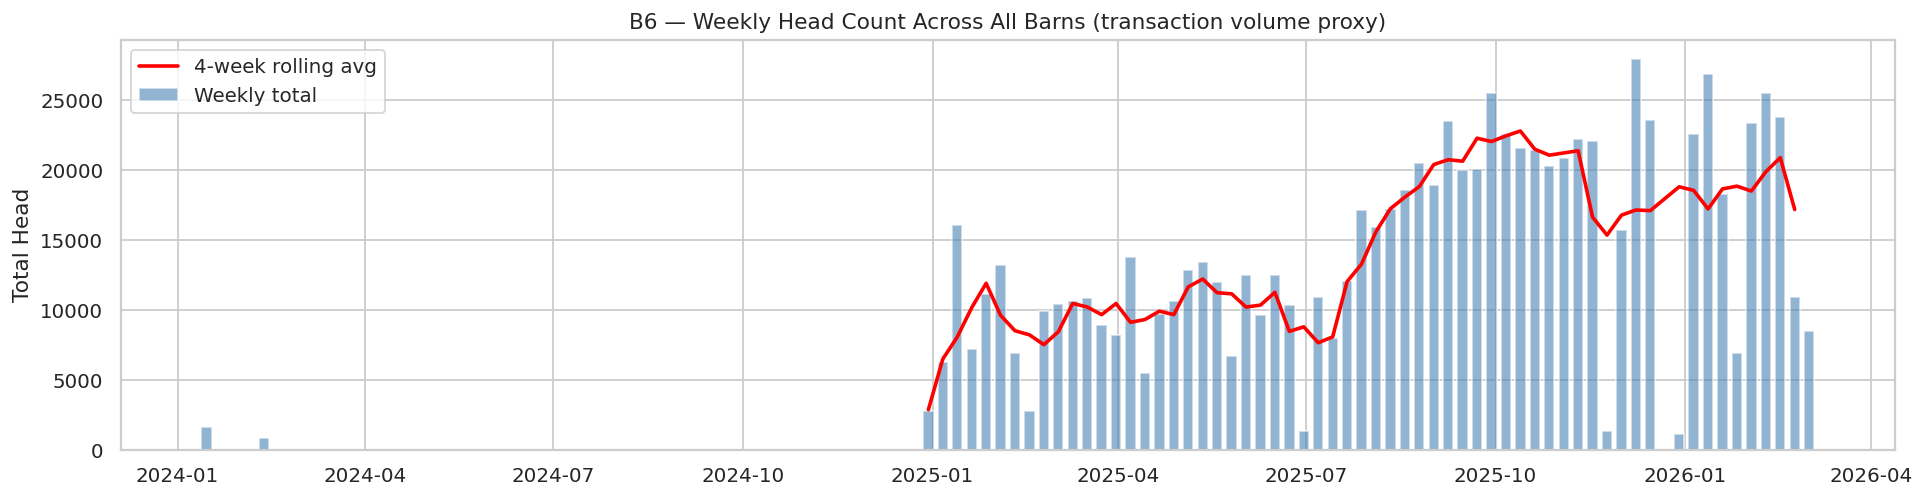

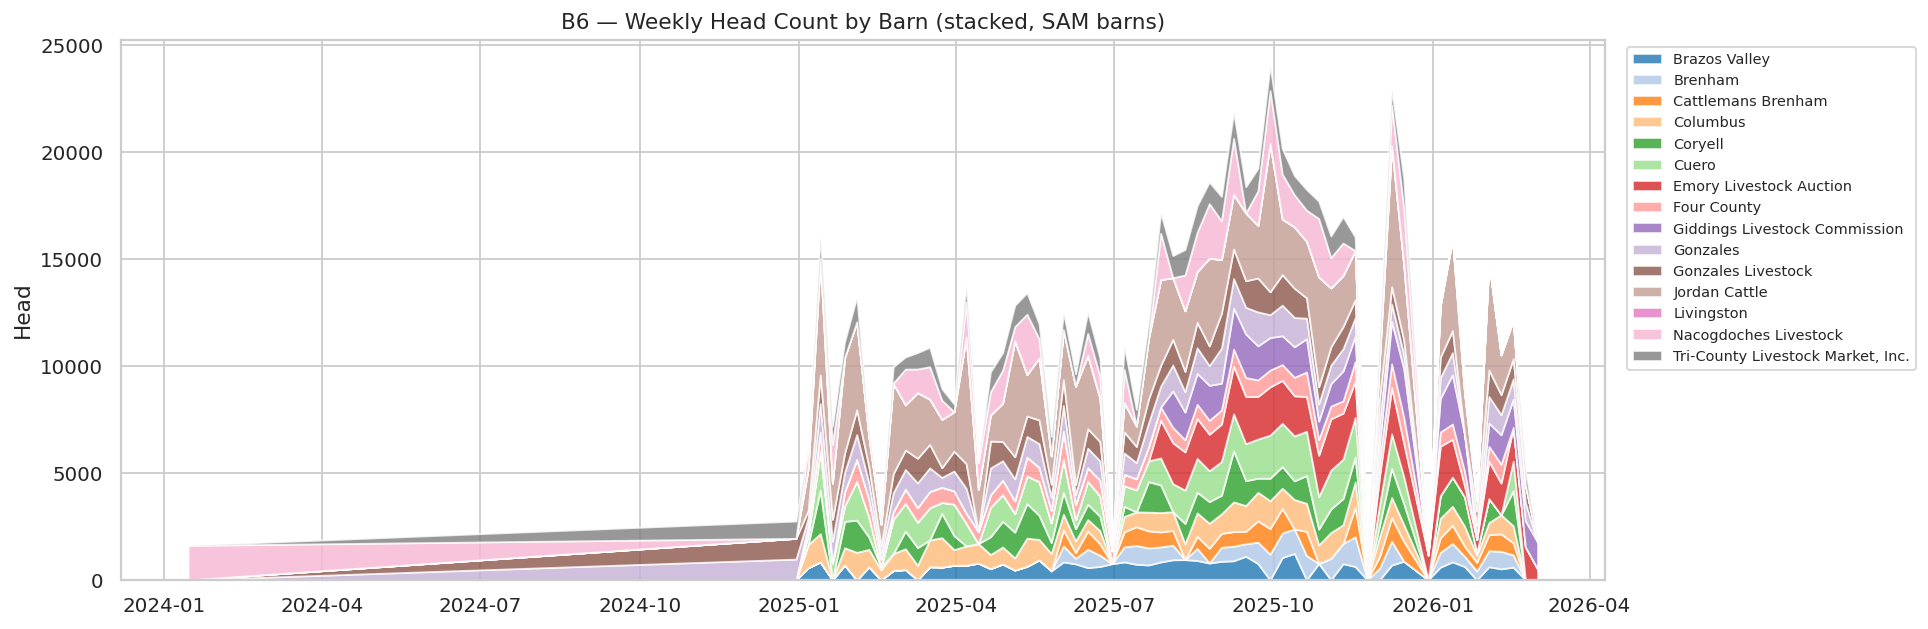

Monthly Head Count by Barn (recent 6 months):


Barn,Beeville Livestock Commission,Brazos Valley,Brenham,Cattlemans Brenham,Columbus,Comanche,Comanche Livestock Exchange,Coryell,Cuero,Decatur,East Texas,Eden livestock,Edinburg,El Campo,Emory Livestock Auction,Flatonia Livestock Auction,Floydada Livestock Sales Co,Four County,Giddings Livestock Commission,Gillespie Livestock Co Inc,Gonzales,Gonzales Livestock,Gulf Coast Livestock Market LLC,Haletsville Livestock,Hondo Livestock Auction,"Hunt Livestock Exchange, LLC",Jordan Cattle,Karnes,La grange(Flatonia),Live Oak,Livingston,Lonestar Stockyards,Lonestar Stockyards (Video/Internet Auction),Milam County Livestock Auction,Nacogdoches Livestock,Navasota,Pearsall,Producers Livestock Auction Co.,Raywood,Southwest Livestock Exchange,Sulphur Springs Livestock Auctions,"Tri-County Livestock Market, Inc.",Tulia Livestock Auction,"Wichita Livestock Sales Co., LLC",wharton
YearMonth,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10,1494.00,3048.00,4624.00,3480.00,5800.00,0.00,154.00,4983.00,9726.00,0.00,0.00,0.00,0.00,0.00,7741.00,0.00,0.00,3497.00,5195.00,0.00,4820.00,4820.00,2728.00,0.00,2085.00,2128.00,20183.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8774.00,0.00,0.00,0.00,2520.00,0.00,0.00,4248.00,0.00,0.00,0.00
2025-11,1526.00,1383.00,3338.00,1387.00,3265.00,776.00,776.00,3492.00,5506.00,0.00,0.00,0.00,0.00,7488.00,7640.00,0.00,0.00,2088.00,3638.00,0.00,3554.00,3554.00,2345.00,0.00,1293.00,1110.00,7439.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5531.00,0.00,0.00,0.00,1385.00,0.00,0.00,3702.00,0.00,0.00,0.00
2025-12,1518.00,1564.00,1651.00,2581.00,2651.00,836.00,836.00,2873.00,3823.00,0.00,0.00,0.00,0.00,6193.00,5068.00,0.00,0.00,3036.00,5008.00,0.00,2567.00,2567.00,1905.00,0.00,533.00,1870.00,11952.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4557.00,0.00,0.00,0.00,675.00,0.00,0.00,3013.00,0.00,0.00,0.00
2026-01,1326.00,2061.00,2430.00,2430.00,3060.00,610.00,531.00,3896.00,0.00,0.00,0.00,0.00,0.00,6501.00,6401.00,0.00,0.00,2047.00,5610.00,0.00,2659.00,2659.00,1500.00,4622.00,1711.00,1480.00,9152.00,0.00,0.00,6666.00,0.00,0.00,0.00,0.00,769.00,1009.00,3717.00,0.00,1301.00,1680.00,0.00,0.00,0.00,0.00,0.00
2026-02,1607.00,1724.00,2136.00,2136.00,2254.00,700.00,961.00,2766.00,1371.00,652.00,1194.00,360.00,362.00,3557.00,6366.00,0.00,0.00,1578.00,5012.00,2331.00,3969.00,3969.00,2480.00,5740.00,1022.00,1260.00,8740.00,0.00,0.00,4329.00,0.00,2213.00,0.00,706.00,0.00,5014.00,2613.00,0.00,1490.00,430.00,0.00,701.00,1017.00,849.00,0.00
2026-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,463.00,0.00,0.00,511.00,970.00,220.00,0.00,1262.00,544.00,0.00,0.00,0.00,0.00,362.00,0.00,0.00,0.00,587.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,653.00,323.00,371.00,0.00,1186.00,0.00,0.00,1064.00,0.00



📌 Annualised Volume Estimates (plug into unit economics model):


,sale_weeks_obs,total_head_obs,avg_per_sale,annualised_52wk
Barn,,,,
Jordan Cattle,55,160182,2912.00,151445.00
Lonestar Stockyards,1,2213,2213.00,115076.00
El Campo,11,23739,2158.00,112221.00
Live Oak,6,10995,1832.00,95290.00
Giddings Livestock Commission,27,40140,1487.00,77307.00
Haletsville Livestock,7,10362,1480.00,76975.00
Cuero,47,63913,1360.00,70712.00
Nacogdoches Livestock,44,57058,1297.00,67432.00
Navasota,5,6023,1205.00,62639.00


In [16]:
# ── 16a. Total weekly volume with rolling average ────────
all_df['Week'] = all_df['Date'].dt.to_period('W').dt.start_time
weekly_vol = all_df.groupby('Week')['Head_Count'].sum().reset_index()
weekly_vol.columns = ['Week','Total_Head']

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(weekly_vol['Week'], weekly_vol['Total_Head'],
       width=5, color='steelblue', alpha=0.6, label='Weekly total')
roll = weekly_vol.set_index('Week')['Total_Head'].rolling(4, center=True).mean()
ax.plot(roll.index, roll.values, color='red', linewidth=2,
        label='4-week rolling avg')
ax.set_title('B6 — Weekly Head Count Across All Barns (transaction volume proxy)')
ax.set_ylabel('Total Head')
ax.legend()
plt.tight_layout()
plt.show()

# ── 16b. Stacked area — SAM barns only ───────────────────
sam_barns6b = (all_df.groupby('Barn')['Date'].count()[lambda s: s>=26]).index.tolist()
barn_wk = (all_df[all_df['Barn'].isin(sam_barns6b)]
           .pivot_table(index='Week', columns='Barn',
                        values='Head_Count', aggfunc='sum')
           .fillna(0))
pal_area = sns.color_palette('tab20', len(barn_wk.columns))

fig, ax = plt.subplots(figsize=(15, 5))
ax.stackplot(barn_wk.index, barn_wk.T.values,
             labels=barn_wk.columns, colors=pal_area, alpha=0.8)
ax.set_title('B6 — Weekly Head Count by Barn (stacked, SAM barns)')
ax.set_ylabel('Head')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

# ── 16c. Monthly volume table + annualised estimates ──────
all_df['YearMonth'] = all_df['Date'].dt.to_period('M')
monthly_vol = (all_df.groupby(['YearMonth','Barn'])['Head_Count']
               .sum().unstack(fill_value=0))
print("Monthly Head Count by Barn (recent 6 months):")
display(monthly_vol.tail(6))

ann_rows = []
for barn, grp in all_df.groupby('Barn'):
    weeks = grp['Date'].nunique()
    total = grp['Head_Count'].sum()
    avg_pw = total / max(weeks, 1)
    ann_rows.append({'Barn': barn,
                     'sale_weeks_obs': weeks,
                     'total_head_obs': int(total) if pd.notna(total) else 0,
                     'avg_per_sale': round(avg_pw, 0),
                     'annualised_52wk': round(avg_pw * 52, 0)})
ann_df = (pd.DataFrame(ann_rows).set_index('Barn')
            .sort_values('annualised_52wk', ascending=False))
print("\n📌 Annualised Volume Estimates (plug into unit economics model):")
display(ann_df)

## Section 17 — Data Quality Summary & Model-Ready Checklist

In [17]:
print("="*60)
print("FINAL DATA QUALITY SUMMARY")
print("="*60)
for name, df in [("all_merged", all_df), ("six_month_barns", six_df)]:
    print(f"\n[{name}]")
    print(f"  Rows              : {len(df):,}")
    print(f"  Date range        : {df['Date'].min().date()} – {df['Date'].max().date()}")
    print(f"  Unique barns      : {df['Barn'].nunique()} → {sorted(df['Barn'].dropna().unique())}")
    print(f"  Rows w/ HeadCount : {df['Head_Count'].notna().sum():,} ({df['Head_Count'].notna().mean()*100:.1f}%)")
    mc = df.isnull().sum().sum()
    tc = df.shape[0] * df.shape[1]
    print(f"  Overall missing   : {mc:,} / {tc:,} cells ({mc/tc*100:.1f}%)")

print("\n" + "="*60)
print("CAPSTONE MODEL — INPUTS READY")
print("="*60)
outputs = {
    "SAM definition":     "completeness_df['in_SAM']",
    "Price benchmarks":   "bench_df (median/mean/p25/p75 by weight class)",
    "Seasonality index":  "s_idx (monthly index, Steer 400-500)",
    "Imputation flag":    "barns_need_impute (barns with <70% col coverage)",
    "Volume estimates":   "ann_df['annualised_52wk']",
    "Barn correlation":   "barn_corr (SAM barns × dates)",
}
for k, v in outputs.items():
    print(f"  ✅ {k:<22} → {v}")
print("\n🎉 EDA complete — ready to populate unit economics model.")

FINAL DATA QUALITY SUMMARY

[all_merged]
  Rows              : 913
  Date range        : 2024-01-16 – 2026-03-05
  Unique barns      : 45 → ['Beeville Livestock Commission', 'Brazos Valley', 'Brenham', 'Cattlemans Brenham', 'Columbus', 'Comanche', 'Comanche Livestock Exchange', 'Coryell', 'Cuero', 'Decatur', 'East Texas', 'Eden livestock', 'Edinburg', 'El Campo', 'Emory Livestock Auction', 'Flatonia Livestock Auction', 'Floydada Livestock Sales Co', 'Four County', 'Giddings Livestock Commission', 'Gillespie Livestock Co Inc', 'Gonzales', 'Gonzales Livestock', 'Gulf Coast Livestock Market LLC', 'Haletsville Livestock', 'Hondo Livestock Auction', 'Hunt Livestock Exchange, LLC', 'Jordan Cattle', 'Karnes', 'La grange(Flatonia)', 'Live Oak', 'Livingston', 'Lonestar Stockyards', 'Lonestar Stockyards (Video/Internet Auction)', 'Milam County Livestock Auction', 'Nacogdoches Livestock', 'Navasota', 'Pearsall', 'Producers Livestock Auction Co.', 'Raywood', 'Southwest Livestock Exchange', 'Sulphu